# GMIC — CMMD2022 Egitim

`DENEY_KEY` hangi deneyin kosulacagini secer; geri kalan her sey sabittir.
Parca 2'nin ciktilarini (`hazir/`) okur.

Su an notebook'ta **Parca 3** var: log semasi, checkpoint, egitim egrileri ve bunlarin testi.
Parca 4-6'da model (global dal, lokal dal) ve egitim dongusu eklenecek.

In [1]:
import os, json, shutil
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'
if ORTAM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

KOK = Path('/content/drive/MyDrive/multiple_instance_classifier' if ORTAM == 'colab' else Path.cwd())
HAZIR_DIR = KOK / 'hazir'
YEREL_AYNA = Path('/content/outputs' if ORTAM == 'colab' else KOK / 'outputs')

with open(HAZIR_DIR / 'config.json', encoding='utf-8') as f:
    VERI_CFG = json.load(f)
GLOBAL_SIZE = tuple(VERI_CFG['GLOBAL_SIZE'])
PATCH_SIZE = VERI_CFG['PATCH_SIZE']
K = VERI_CFG['K']
ESIK = VERI_CFG['ESIK']
SEED = VERI_CFG['SEED']
# augmentasyon parametreleri de Parca 2'nin config'inden gelir (tek kaynak)
MAX_CROP_NOISE = tuple(VERI_CFG['MAX_CROP_NOISE'])
MAX_CROP_SIZE_NOISE = VERI_CFG['MAX_CROP_SIZE_NOISE']
print('ortam:', ORTAM, '| GLOBAL_SIZE:', GLOBAL_SIZE, '| K:', K, '| yama:', PATCH_SIZE)
print('augmentasyon: crop noise', MAX_CROP_NOISE, '| size noise', MAX_CROP_SIZE_NOISE)
print('normalizasyon:', VERI_CFG['normalizasyon'])

Mounted at /content/drive
ortam: colab | GLOBAL_SIZE: (2304, 1280) | K: 6 | yama: 256
augmentasyon: crop noise (100, 100) | size noise 100
normalizasyon: goruntu basina z-score, istatistikler maske ici (piksel > ESIK)


## Deney secimi

Makaledeki Tablo 1 ablasyonu + CMMD'ye ozgu uc ek deney. **Uc deney egitim gerektirmez**
(`gmic_loc`, `gmic_mil`, `gmic_loc_random`); baska kosularin ciktilarindan degerlendirme
asamasinda turetilir.

`gmic_ft_scratch` notu: plandaki ilk fikir `f_d`'yi ImageNet ile tohumlamakti, ama ResNet-22
Wu ve ark.'nin ozel mimarisi ve yayinlanmis ImageNet agirligi yok. Ayni soru (kucuk veride
on-egitim ne kadar tasiyor) tersinden olculuyor: `f_t` ImageNet'siz kosuluyor.

In [2]:
DENEY_KEY = 'gmic'   # asagidaki DENEYLER icinden

DENEYLER = {
    # egitilen kosular
    'resnet22_baseline': dict(mimari='baseline', not_='f_d + GAP + FC (Wu ve ark. 2019)'),
    'gmic':              dict(mimari='gmic',     not_='tam model'),
    'gmic_noattn':       dict(mimari='gmic', attention='esit', not_='alpha_k = 1/K'),
    'gmic_random':       dict(mimari='gmic', yama='rastgele',  not_='MIL rastgele yamalarda'),
    'gmic_ft_scratch':   dict(mimari='gmic', ft_pretrained=False,
                              not_='f_t ImageNet siz (on-egitimin katkisi)'),
    'gmic_lowres':       dict(mimari='gmic', global_size=(1152, 640), not_='yarim cozunurluk'),
    'gmic_augment':      dict(mimari='gmic', augment=True, not_='ek augmentasyon (NYU da yok)'),
    # turetilen (egitim yok, Parca 9'da hesaplanir)
    'gmic_loc':         dict(turetilmis='gmic',                     not_='y_loc'),
    'gmic_mil':         dict(turetilmis='gmic',                     not_='y_mil'),
    'gmic_loc_random':  dict(turetilmis=('gmic', 'gmic_random'),    not_='(y_loc + y_random)/2'),
}
CFG = dict(DENEYLER[DENEY_KEY])
assert 'turetilmis' not in CFG, f'{DENEY_KEY} egitilmez, Parca 9 da turetilir'

# deneye ozel cozunurluk (gmic_lowres)
if CFG.get('global_size'):
    GLOBAL_SIZE = tuple(CFG['global_size'])

# makaledeki sabitler
MAX_EPOCHS = 40
PATIENCE = 10
L = 128                      # MIL ozellik boyutu
BATCH = 16
GRAD_ACCUM = 1               # efektif batch 16
CLIP = 1.0

# Parca 7 aramasinin ciktisi: 12 kosu x 15 epoch, en iyi = kosu 05 (val malign AUC 0.8133)
# arama/secim.json ile ayni; degistirilirse arama gecersiz kalir
HP = dict(lr=6.148217e-05, lam=6.025001e-05, beta=4.5097, t=0.15350)

DENEY_DIR = KOK / DENEY_KEY
CKPT_DIR = DENEY_DIR / 'checkpoints'
CASES_DIR = DENEY_DIR / f'{DENEY_KEY}_cases'
for d in [DENEY_DIR, CKPT_DIR, CASES_DIR, YEREL_AYNA / DENEY_KEY]:
    d.mkdir(parents=True, exist_ok=True)

EXCEL_LOG = DENEY_DIR / f'{DENEY_KEY}_log.xlsx'
CURVES_PNG = DENEY_DIR / f'{DENEY_KEY}_curves.png'
BEST_CKPT = CKPT_DIR / 'best.pt'
LAST_CKPT = CKPT_DIR / 'last.pt'
TEST_OZET = DENEY_DIR / f'{DENEY_KEY}_test_summary.xlsx'
TEST_TAHMIN = DENEY_DIR / f'{DENEY_KEY}_test_tahminler.xlsx'

print(f'deney   : {DENEY_KEY}  ({CFG["not_"]})')
print(f'cozunurluk: {GLOBAL_SIZE}')
print(f'cikti   : {DENEY_DIR}')

deney   : gmic  (tam model)
cozunurluk: (2304, 1280)
cikti   : /content/drive/MyDrive/multiple_instance_classifier/gmic


In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch

try:
    import cv2
except ImportError:
    !pip -q install opencv-python-headless
    import cv2

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device', DEVICE)

torch 2.11.0+cu128 | device cuda


## Log semasi

Epoch basina tek satir, Excel'e canli yazilir. Kolonlarin secim gerekcesi `PLAN.md` Bolum 8'de;
ozetle:

- Kayip **uc bileseni ayri** (`bce_loc`, `bce_mil`, `reg`): `lam * L_reg` saliency map'i sifira
  bastirdiginda bu toplam kayiptan gorulmez, GMIC'in bilinen basarisizlik modu bu.
- `auc_malign` birincil olcut: `best.pt` ve early stopping buna bakar (makale de model secimini
  val malign AUC ile yapiyor).
- `auc_malign_loc` / `auc_malign_mil` her epoch ayri: Tablo 1'in loc/mil satirlari ayni kosudan
  okunuyor, ayrica iki dalin hangi epoch'ta ayristigi yalnizca burada gorulur.
- `attn_entropi` = -sum(alpha log alpha): dikkat tek yamaya kilitlendiginde 0'a, hic secim
  yapmadiginda log(K)=1.79'a gider. Kayiptan gorulmez.
- `sm_ort_aktivasyon` = mean(A): regularization'in saliency map'i ne kadar bastirdigi.
- `sm_meme_ici_oran`: aktivasyonun meme maskesi icinde kalan payi -- piksel maskesi olmadigi icin
  lokalizasyon vekil olcutu.

Tum val metrikleri **meme seviyesinde** (CC + MLO tahmin ortalamasi), makalenin tanimi.

In [4]:
SCHEMA = [
    'epoch',
    'train_loss', 'train_bce_loc', 'train_bce_mil', 'train_reg',
    'val_loss', 'val_bce_loc', 'val_bce_mil', 'val_reg',
    'auc_malign', 'auc_benign',
    'auc_malign_loc', 'auc_malign_mil',
    'acc', 'precision_malign', 'recall_malign', 'f1_malign',
    'attn_entropi', 'sm_ort_aktivasyon', 'sm_meme_ici_oran',
    'lr', 'grad_norm',
]
AUC_YLIM = (0.5, 1.0)     # 10 deneyin figuru yan yana konacak, olcek sabit
ORAN_YLIM = (0.0, 1.0)


def append_epoch_row(excel_yolu, satir, resume_epoch=None):
    """Epoch satirini Excel'e ekler. resume_epoch verilirse o epoch ve sonrasi atilir."""
    if os.path.exists(excel_yolu):
        df = pd.read_excel(excel_yolu)
        if resume_epoch is not None:
            df = df[df['epoch'] < resume_epoch]
        satirlar = df.to_dict('records')
    else:
        satirlar = []
    satirlar.append({k: satir.get(k) for k in SCHEMA})
    pd.DataFrame(satirlar)[SCHEMA].to_excel(excel_yolu, index=False)
    return len(satirlar)


def mirror_to_local(yol):
    """Drive'a yazilani yerel aynaya kopyalar (oturum koparsa cikti kaybolmasin)."""
    yol = Path(yol)
    hedef = YEREL_AYNA / DENEY_KEY / yol.name
    hedef.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(yol, hedef)
    return hedef

## Checkpoint

`last.pt` her epoch uzerine yazilir, `best.pt` yalnizca val malign AUC iyilestiginde.
`epochs_without_improve` checkpoint'te tutulur -- yoksa resume'da early stopping sayaci sifirlanir
(`mendeley_data_density`'de yasanmis hata). RNG state de saklanir, resume tekrarlanabilir olsun.

In [5]:
def save_checkpoint(yol, model, optimizer, scaler, epoch, best_auc, epochs_without_improve=0):
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler': scaler.state_dict() if scaler is not None else None,
        'epoch': epoch,
        'best_auc': best_auc,
        'epochs_without_improve': epochs_without_improve,
        'torch_rng_state': torch.get_rng_state(),
        'numpy_rng_state': np.random.get_state(),
        'deney': DENEY_KEY,
        'hp': HP,
        'global_size': list(GLOBAL_SIZE),
        'batch': BATCH,
        'grad_accum': GRAD_ACCUM,
    }, yol)


def restore_checkpoint(ckpt, model, optimizer, scaler):
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    if scaler is not None and ckpt.get('scaler') is not None:
        scaler.load_state_dict(ckpt['scaler'])
    torch.set_rng_state(ckpt['torch_rng_state'].cpu())
    np.random.set_state(ckpt['numpy_rng_state'])
    return ckpt['epoch'], ckpt['best_auc'], ckpt.get('epochs_without_improve', 0)


def find_resumable_checkpoint():
    """Eksik/bozuk checkpoint'te sessizce sifirdan baslamak yerine acikca hata verir."""
    if not os.path.exists(LAST_CKPT):
        raise FileNotFoundError(f'Resume edilebilir checkpoint yok: {LAST_CKPT}')
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE, weights_only=False)
    for k in ['epoch', 'optimizer', 'model']:
        if k not in ckpt:
            raise RuntimeError(f'{LAST_CKPT} eksik/bozuk ({k} yok) -- resume edilemez.')
    if ckpt.get('deney') != DENEY_KEY:
        raise RuntimeError(f"checkpoint baska deneye ait: {ckpt.get('deney')} != {DENEY_KEY}")
    if tuple(ckpt.get('global_size', GLOBAL_SIZE)) != tuple(GLOBAL_SIZE):
        raise RuntimeError('checkpoint farkli cozunurlukle egitilmis')
    # BatchNorm istatistikleri batch boyutuna bagli ve lr o batch altinda secildi ->
    # batch degistirip resume etmek sessiz bir tutarsizlik olurdu. Eski checkpointlerde
    # bu kayit yok, o durumda kontrol atlanir.
    eski_batch = (ckpt.get('batch'), ckpt.get('grad_accum'))
    if eski_batch[0] is not None and eski_batch != (BATCH, GRAD_ACCUM):
        raise RuntimeError(f'checkpoint (batch, grad_accum) = {eski_batch} ile egitilmis, '
                           f'simdi {(BATCH, GRAD_ACCUM)} -- BatchNorm ve lr uyumsuz')
    return ckpt

## Egitim egrileri

2x3 panel. AUC panellerinde olcek sabit (0.5-1.0) -- 10 deneyin figuru rapora yan yana konacak,
otomatik olcek kucuk dalgalanmayi kararsizlik gibi gosteriyor (`mendeley_data_density`'de
`METRIC_YLIM` ayni gerekceyle sabitlendi).

Sag alt panel GMIC'e ozgu teshis: dikkat entropisi ile saliency map ortalama aktivasyonu.

In [6]:
def plot_training_curves(excel_yolu, cikti, baslik):
    df = pd.read_excel(excel_yolu)
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    a = ax[0, 0]
    a.plot(df.epoch, df.train_loss, lw=2, color='tab:blue', label='train')
    a.plot(df.epoch, df.val_loss, lw=2, ls='--', color='tab:blue', label='val')
    for k, c in [('train_bce_loc', 'tab:orange'), ('train_bce_mil', 'tab:green'),
                 ('train_reg', 'tab:red')]:
        if df[k].notna().any():
            a.plot(df.epoch, df[k], lw=1, alpha=0.6, color=c, label=k.replace('train_', ''))
    a.set_title('Kayip ve bilesenleri'); a.set_xlabel('epoch'); a.set_ylim(0, None)
    a.legend(fontsize=8); a.grid(alpha=0.3)

    a = ax[0, 1]
    a.plot(df.epoch, df.auc_malign, marker='o', ms=3, lw=2, color='tab:red', label='GMIC')
    for k, c, ad in [('auc_malign_loc', 'tab:blue', 'loc'), ('auc_malign_mil', 'tab:green', 'mil')]:
        if df[k].notna().any():
            a.plot(df.epoch, df[k], lw=1, alpha=0.7, color=c, label=ad)
    if df.auc_malign.notna().any():
        i = int(df.auc_malign.idxmax())
        a.axvline(df.epoch[i], ls='--', lw=1, color='k')
        # etiket sag kenardan tasmasin: zirve son ceyrekteyse sola yerlestir
        sag = df.epoch[i] > df.epoch.iloc[0] + 0.75 * (df.epoch.iloc[-1] - df.epoch.iloc[0])
        a.annotate(f'zirve ep{int(df.epoch[i])}: {df.auc_malign[i]:.3f}',
                   (df.epoch[i], df.auc_malign[i]), textcoords='offset points',
                   xytext=(-104 if sag else 6, -40), fontsize=8.5,
                   bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#bbb', alpha=0.9))
    a.set_ylim(*AUC_YLIM); a.set_title('Val AUC — malign (checkpoint olcutu)')
    a.set_xlabel('epoch'); a.legend(fontsize=8); a.grid(alpha=0.3)

    a = ax[0, 2]
    a.plot(df.epoch, df.auc_benign, marker='o', ms=3, color='tab:purple')
    a.set_ylim(*AUC_YLIM); a.set_title('Val AUC — benign'); a.set_xlabel('epoch'); a.grid(alpha=0.3)

    a = ax[1, 0]
    for k, c in [('precision_malign', 'tab:orange'), ('recall_malign', 'tab:red'),
                 ('f1_malign', 'tab:brown')]:
        a.plot(df.epoch, df[k], lw=1.5, color=c, label=k.replace('_malign', ''))
    a.set_ylim(*ORAN_YLIM); a.set_title('Malign P / R / F1 (esik 0.5, meme seviyesi)')
    a.set_xlabel('epoch'); a.legend(fontsize=8); a.grid(alpha=0.3)

    a = ax[1, 1]
    a.plot(df.epoch, df.lr, color='tab:brown', label='lr')
    a.set_yscale('log'); a.set_ylabel('lr'); a.set_xlabel('epoch')
    a.grid(alpha=0.3, which='both')
    b = a.twinx()
    b.plot(df.epoch, df.grad_norm, color='tab:purple', lw=1, alpha=0.8, label='grad_norm')
    b.axhline(CLIP, ls='--', lw=1, color='k')
    b.set_yscale('log'); b.set_ylabel('grad_norm')
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = b.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, fontsize=8, loc='lower left')
    a.set_title(f'LR (sol eksen) ve gradyan normu (sag eksen, kesikli: clip {CLIP})',
                fontsize=10)

    a = ax[1, 2]
    a.plot(df.epoch, df.attn_entropi, color='tab:cyan', lw=1.8, label='dikkat entropisi')
    a.axhline(np.log(K), ls='--', lw=1, color='k')
    a.annotate(f'log K = {np.log(K):.2f} (esit dikkat)', (df.epoch.iloc[0], np.log(K)),
               textcoords='offset points', xytext=(4, 4), fontsize=8)
    a.set_ylim(0, np.log(K) * 1.15); a.set_ylabel('entropi'); a.set_xlabel('epoch')
    b = a.twinx()
    b.plot(df.epoch, df.sm_ort_aktivasyon, color='tab:olive', lw=1.8, label='mean(A)')
    b.plot(df.epoch, df.sm_meme_ici_oran, color='tab:gray', lw=1, ls=':', label='meme ici oran')
    b.set_ylim(0, 1); b.set_ylabel('saliency map')
    a.set_title('Dikkat entropisi + saliency map (GMIC teshis paneli)')
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = b.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, fontsize=8, loc='center right')
    a.grid(alpha=0.3)

    plt.suptitle(baslik, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(cikti, dpi=140, bbox_inches='tight')
    plt.show()

## Altyapi testi

Model olmadan calisir: sentetik epoch satirlari uretip Excel yazimini, resume davranisini,
checkpoint kaydet/geri yukle turunu ve grafigi dogrular. Gecmesi gereken kontroller `assert`
ile yazili.

In [7]:
TEST_DIR = KOK / '_altyapi_testi'
TEST_DIR.mkdir(exist_ok=True)
test_log = TEST_DIR / 'test_log.xlsx'
if test_log.exists():
    test_log.unlink()

rng = np.random.default_rng(SEED)


def sentetik_satir(e, n=40):
    """Gerceklige benzer egri: kayip duser, AUC yukselir, dikkat entropisi dagilir."""
    p = e / n
    bce_loc = 0.68 * np.exp(-1.8 * p) + 0.05 + rng.normal(0, 0.01)
    bce_mil = 0.70 * np.exp(-2.2 * p) + 0.04 + rng.normal(0, 0.012)
    reg = 0.30 * np.exp(-3.0 * p) + 0.01
    auc = 0.55 + 0.30 * (1 - np.exp(-3.2 * p)) + rng.normal(0, 0.008)
    return dict(
        epoch=e,
        train_loss=bce_loc + bce_mil + reg, train_bce_loc=bce_loc,
        train_bce_mil=bce_mil, train_reg=reg,
        val_loss=(bce_loc + bce_mil) * 1.08 + reg, val_bce_loc=bce_loc * 1.08,
        val_bce_mil=bce_mil * 1.08, val_reg=reg,
        auc_malign=auc, auc_benign=auc - 0.09,
        auc_malign_loc=auc - 0.015, auc_malign_mil=auc - 0.022,
        acc=0.5 + 0.28 * p, precision_malign=0.55 + 0.25 * p,
        recall_malign=0.60 + 0.22 * p, f1_malign=0.57 + 0.24 * p,
        attn_entropi=np.log(K) * (1 - 0.45 * p), sm_ort_aktivasyon=0.35 * np.exp(-1.2 * p) + 0.04,
        sm_meme_ici_oran=0.45 + 0.45 * (1 - np.exp(-2.5 * p)),
        lr=HP['lr'] * (0.5 ** (e // 12)), grad_norm=1.6 * np.exp(-2.0 * p) + 0.15,
    )


for e in range(40):
    n = append_epoch_row(test_log, sentetik_satir(e))
assert n == 40, n
df = pd.read_excel(test_log)
assert list(df.columns) == SCHEMA, 'kolon sirasi SCHEMA ile ayni degil'
assert df.epoch.is_monotonic_increasing and df.epoch.is_unique
print('40 epoch yazildi, sema dogru.')

# resume: epoch 25'ten devam edilince 25 ve sonrasi silinmeli
n = append_epoch_row(test_log, sentetik_satir(25), resume_epoch=25)
df = pd.read_excel(test_log)
assert n == 26 and len(df) == 26, (n, len(df))
assert df.epoch.max() == 25 and df.epoch.is_unique, 'resume sonrasi epoch tekrari'
print('resume testi gecti: 40 satir -> 26 satir, tekrar yok.')

# bastan yazma testi
for e in range(26, 40):
    append_epoch_row(test_log, sentetik_satir(e))
print('tamamlandi:', len(pd.read_excel(test_log)), 'satir')

40 epoch yazildi, sema dogru.
resume testi gecti: 40 satir -> 26 satir, tekrar yok.
tamamlandi: 40 satir


In [8]:
# checkpoint kaydet/geri yukle turu (kucuk sahte model)
kukla = torch.nn.Sequential(torch.nn.Linear(4, 3), torch.nn.ReLU(), torch.nn.Linear(3, 2))
opt = torch.optim.Adam(kukla.parameters(), lr=HP['lr'])
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

kukla(torch.randn(2, 4)).sum().backward()
opt.step()
onceki = kukla[0].weight.detach().clone()

test_ckpt = TEST_DIR / 'test_last.pt'
save_checkpoint(test_ckpt, kukla, opt, scaler, epoch=25, best_auc=0.842,
                epochs_without_improve=3)

# checkpoint kaydedildikten SONRA cekilen sayilar, resume sonrasi ayni gelmeli
kayit_sonrasi = torch.randn(3)

# agirliklari boz, sonra geri yukle
with torch.no_grad():
    kukla[0].weight.mul_(0)
ckpt = torch.load(test_ckpt, map_location=DEVICE, weights_only=False)
e, best, sayac = restore_checkpoint(ckpt, kukla, opt, scaler)

assert torch.allclose(kukla[0].weight, onceki), 'agirlik geri yuklenmedi'
assert (e, best, sayac) == (25, 0.842, 3), (e, best, sayac)
assert ckpt['deney'] == DENEY_KEY and tuple(ckpt['global_size']) == tuple(GLOBAL_SIZE)
print(f'checkpoint turu gecti: epoch {e}, best_auc {best}, iyilesmeyen {sayac}')

# RNG state geri yuklendi mi: kaydin ardindan gelen sayilar tekrar uretilmeli
resume_sonrasi = torch.randn(3)
assert torch.allclose(kayit_sonrasi, resume_sonrasi), 'RNG state geri yuklenmedi'
print('RNG state testi gecti (resume tekrarlanabilir).')

# bozuk checkpoint acikca hata vermeli
bozuk = TEST_DIR / 'bozuk.pt'
torch.save({'model': kukla.state_dict()}, bozuk)
_yedek = LAST_CKPT
try:
    globals()['LAST_CKPT'] = bozuk
    try:
        find_resumable_checkpoint()
        raise AssertionError('bozuk checkpoint hata vermedi')
    except RuntimeError as err:
        print('bozuk checkpoint dogru sekilde reddedildi:', err)
finally:
    globals()['LAST_CKPT'] = _yedek

checkpoint turu gecti: epoch 25, best_auc 0.842, iyilesmeyen 3
RNG state testi gecti (resume tekrarlanabilir).
bozuk checkpoint dogru sekilde reddedildi: /content/drive/MyDrive/multiple_instance_classifier/_altyapi_testi/bozuk.pt eksik/bozuk (epoch yok) -- resume edilemez.


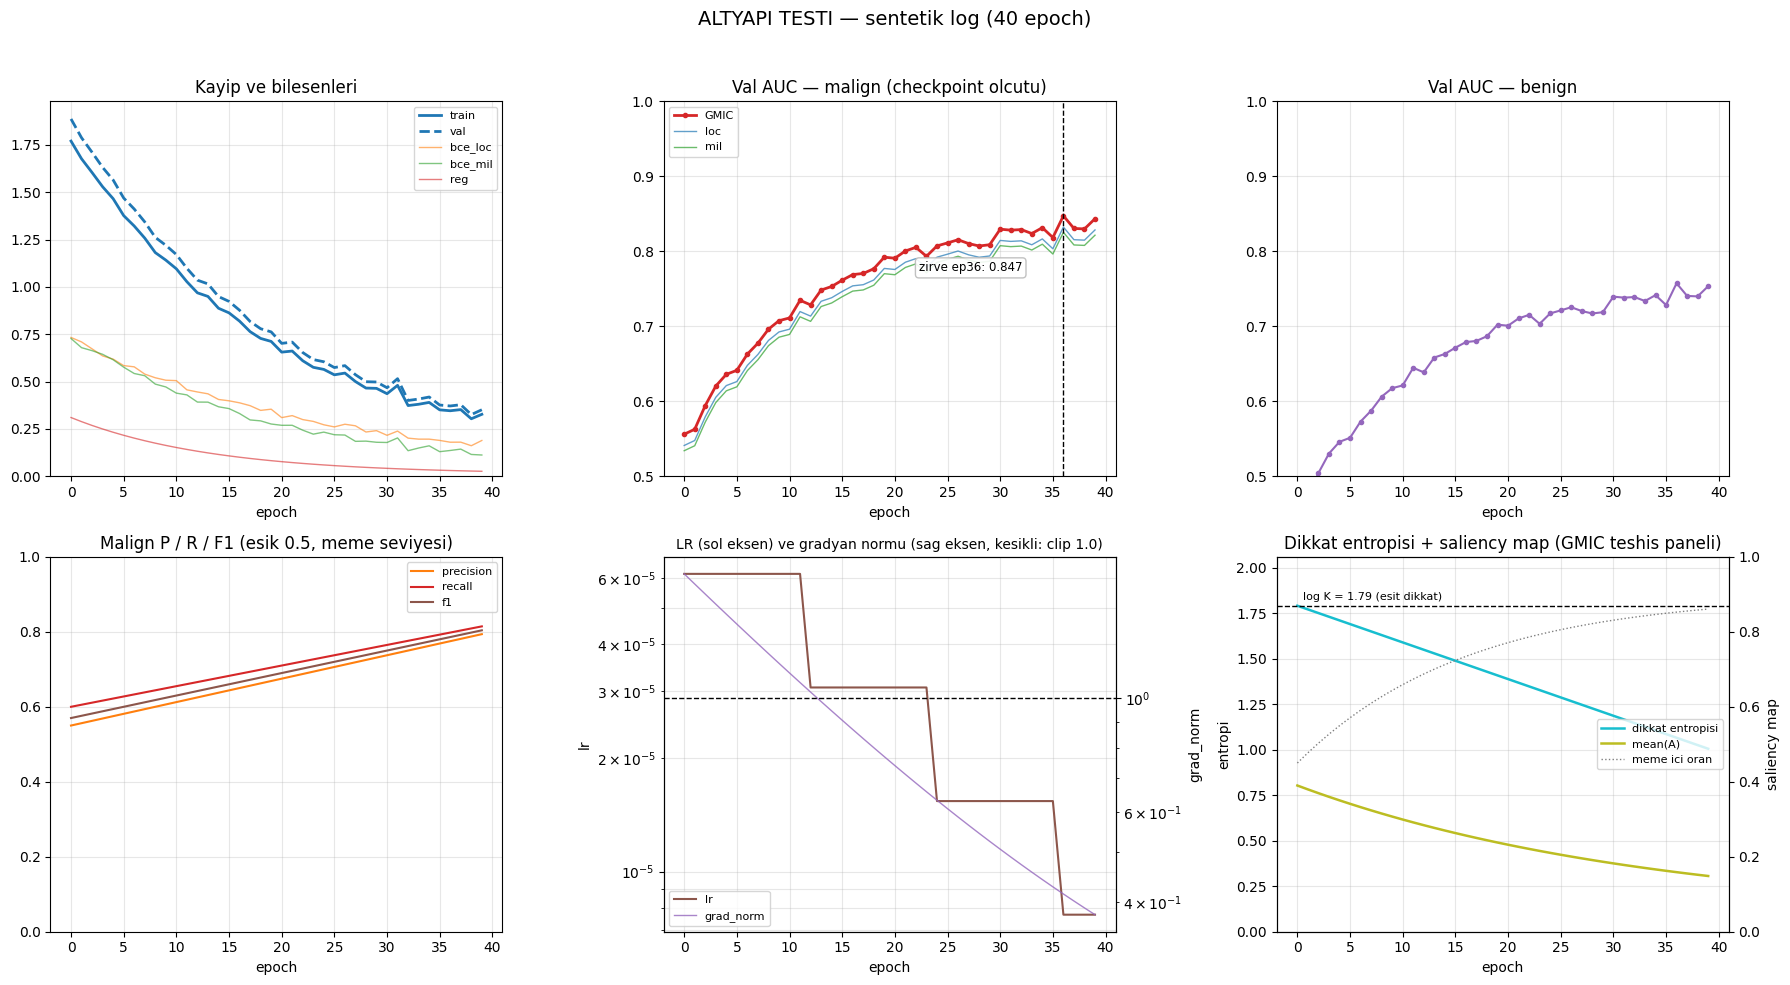

grafik uretildi: /content/drive/MyDrive/multiple_instance_classifier/_altyapi_testi/test_curves.png

Parca 3 altyapisi hazir. Parca 4: global dal (ResNet-22 + saliency map + f_agg).


In [9]:
plot_training_curves(test_log, TEST_DIR / 'test_curves.png',
                     f'ALTYAPI TESTI — sentetik log ({len(pd.read_excel(test_log))} epoch)')
print('grafik uretildi:', TEST_DIR / 'test_curves.png')
print('\nParca 3 altyapisi hazir. Parca 4: global dal (ResNet-22 + saliency map + f_agg).')

## Parca 4 — Global dal (`f_d`) + saliency map + `f_agg`

Mimari NYU'nun yayinladigi koddan (`nyukat/GMIC`, `src/modeling/modules.py`) birebir alindi:

| Parametre | Deger (koddan) |
|---|---|
| `input_channels` | **1** (gri tonlu, 3 kanala kopyalanmiyor) |
| `num_filters` | 16, `growth_factor` 2 -> 16, 32, 64, 128, 256 |
| ilk katman | 7x7 conv, stride 2, padding 3 |
| ilk pool | 3x3 max, stride 2 |
| `blocks_per_layer_list` | [2, 2, 2, 2, 2] |
| `block_strides_list` | [1, 2, 2, 2, 2] |
| saliency map | `Conv2d(256, num_classes, 1x1, bias=False)` + sigmoid |
| `f_agg` | `top_t = round(H*W*t)`, `topk(...).mean()` |

Toplam downsampling 2 (conv) x 2 (pool) x 16 (block stride'lari) = **64**. Bu, makalenin
2944x1920 girdisinde 46x30'luk saliency map verir; bizim 2304x1280 girdimizde **36x20**.

ResNet**V2** = pre-activation blok (BN -> ReLU -> conv), son katmandan sonra BN + ReLU.

In [10]:
import torch.nn as nn
import torch.nn.functional as F


class BasicBlockV2(nn.Module):
    """Pre-activation ResNet blogu (BN -> ReLU -> conv), ResNetV2 deseni."""

    def __init__(self, giris, cikis, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(giris)
        self.conv1 = nn.Conv2d(giris, cikis, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cikis)
        self.conv2 = nn.Conv2d(cikis, cikis, 3, padding=1, bias=False)
        self.kisayol = None
        if stride != 1 or giris != cikis:
            self.kisayol = nn.Conv2d(giris, cikis, 1, stride=stride, bias=False)

    def forward(self, x):
        o = F.relu(self.bn1(x))
        yan = self.kisayol(o) if self.kisayol is not None else x
        o = self.conv1(o)
        o = self.conv2(F.relu(self.bn2(o)))
        return o + yan


class ResNetV2(nn.Module):
    """f_d: ResNet-22 (az filtreli, GAP + FC yok). NYU parametreleri."""

    def __init__(self, input_channels=1, num_filters=16,
                 blocks_per_layer_list=(2, 2, 2, 2, 2),
                 block_strides_list=(1, 2, 2, 2, 2), growth_factor=2):
        super().__init__()
        self.ilk_conv = nn.Conv2d(input_channels, num_filters, 7, stride=2, padding=3, bias=False)
        self.ilk_pool = nn.MaxPool2d(3, stride=2, padding=0)

        katmanlar = []
        giris = num_filters
        for n_blok, stride in zip(blocks_per_layer_list, block_strides_list):
            # stride 1 olan ilk kademe kanal sayisini korur, digerleri growth_factor kadar buyutur
            cikis = giris * growth_factor if stride != 1 else giris
            bloklar = [BasicBlockV2(giris, cikis, stride)]
            bloklar += [BasicBlockV2(cikis, cikis) for _ in range(n_blok - 1)]
            katmanlar.append(nn.Sequential(*bloklar))
            giris = cikis
        self.katmanlar = nn.Sequential(*katmanlar)
        self.son_bn = nn.BatchNorm2d(giris)
        self.cikis_kanal = giris

    def forward(self, x):
        o = self.ilk_pool(self.ilk_conv(x))
        o = self.katmanlar(o)
        return F.relu(self.son_bn(o))

In [11]:
def f_agg(A, t):
    """top-t% ortalamasi (GAP ile GMP arasi yumusak denge). A: (B, C, H, W) -> (B, C)."""
    B, C, H, W = A.shape
    top_t = max(int(round(H * W * t)), 1)
    duz = A.reshape(B, C, -1)
    return duz.topk(top_t, dim=2)[0].mean(dim=2)


def L_reg(A, beta, eps=1e-6):
    """sum |A|^beta, ornek basina ortalanir. A zaten [0,1] araliginda.

    clamp_min gerekcesi: turev beta*|A|^(beta-1), yani beta < 1 iken A -> 0'da sonsuz.
    AMP altinda sigmoid buyuk negatif logitte tam 0'a underflow ettigi icin bu pratikte
    olusuyordu (arama kosu 06: beta 0.899, mean(A) 0.14 -> NaN -> BCE device-side assert).
    Kayba etkisi ihmal edilebilir: 1440 elemanin hepsi sifir olsa eklenen miktar ~0.006,
    reg degerleri 50-650 araliginda.
    """
    return A.abs().clamp_min(eps).pow(beta).sum(dim=(1, 2, 3)).mean()


class GlobalNetwork(nn.Module):
    """f_d + 1x1 conv + sigmoid -> saliency map A; f_agg ile y_loc."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.fd = ResNetV2(input_channels=1)
        self.sm_conv = nn.Conv2d(self.fd.cikis_kanal, num_classes, 1, bias=False)

    def forward(self, x):
        h = self.fd(x)                      # (B, 256, H/64, W/64)
        A = torch.sigmoid(self.sm_conv(h))  # (B, C, h, w), her eleman [0,1]
        return A, h


class Resnet22Baseline(nn.Module):
    """Wu ve ark. 2019 baseline: f_d + GAP + FC."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.fd = ResNetV2(input_channels=1)
        self.fc = nn.Linear(self.fd.cikis_kanal, num_classes)

    def forward(self, x, rng=None):
        # GMIC ile ayni sozluk arayuzu: kayip ve metrik yolu tek kalsin.
        # Baseline'da saliency map, yama ve attention yok -> None (metriklerde NaN olarak gecer).
        y = torch.sigmoid(self.fc(self.fd(x).mean(dim=(2, 3))))
        return dict(A=None, y_loc=None, y_mil=None, y=y, alpha=None, pozlar=None)

### Sekil ve dogruluk testleri

`f_agg`'in elle hesaplanan top-t% ortalamasiyla ayni sonucu verdigi, saliency map boyutunun
beklenen 1/64 oldugu ve gradyanin `f_d`'ye aktigi kontrol edilir.

In [12]:
torch.manual_seed(SEED)
gnet = GlobalNetwork(num_classes=2)
n_par = sum(p.numel() for p in gnet.parameters())
print(f'GlobalNetwork parametre: {n_par/1e6:.2f} M')

# kucuk girdiyle sekil testi (CPU'da tam cozunurluk agir)
for boyut in [(256, 256), (512, 320), GLOBAL_SIZE]:
    if boyut == GLOBAL_SIZE and DEVICE == 'cpu':
        print(f'{boyut}: CPU da atlandi (bellek/sure); beklenen SM '
              f'{boyut[0]//64}x{boyut[1]//64}')
        continue
    with torch.no_grad():
        A, h = gnet(torch.randn(1, 1, *boyut))
    assert A.shape == (1, 2, boyut[0] // 64, boyut[1] // 64), A.shape
    print(f'girdi {boyut} -> ozellik {tuple(h.shape)} -> saliency map {tuple(A.shape)}')

# saliency map [0,1] araliginda mi
with torch.no_grad():
    A, _ = gnet(torch.randn(2, 1, 256, 256))
assert A.min() >= 0 and A.max() <= 1, (A.min().item(), A.max().item())
print(f'saliency map araligi: [{A.min():.4f}, {A.max():.4f}]')

GlobalNetwork parametre: 2.80 M
girdi (256, 256) -> ozellik (1, 256, 4, 4) -> saliency map (1, 2, 4, 4)
girdi (512, 320) -> ozellik (1, 256, 8, 5) -> saliency map (1, 2, 8, 5)
girdi (2304, 1280) -> ozellik (1, 256, 36, 20) -> saliency map (1, 2, 36, 20)
saliency map araligi: [0.3181, 0.6703]


In [13]:
# f_agg: elle hesapla ve karsilastir
A_test = torch.rand(3, 2, 36, 20)
t = HP['t']
beklenen_k = max(int(round(36 * 20 * t)), 1)
elle = torch.stack([torch.stack([A_test[b, c].flatten().sort(descending=True)[0][:beklenen_k].mean()
                                for c in range(2)]) for b in range(3)])
assert torch.allclose(f_agg(A_test, t), elle, atol=1e-6)
print(f'f_agg dogru: t={t:.4f} -> top_t={beklenen_k} / {36*20} konum ({100*beklenen_k/720:.1f}%)')

# t = 1.0 -> GAP,  t -> 0 -> GMP  (makaledeki iki uc)
assert torch.allclose(f_agg(A_test, 1.0), A_test.mean(dim=(2, 3)), atol=1e-6)
assert torch.allclose(f_agg(A_test, 1e-9), A_test.amax(dim=(2, 3)), atol=1e-6)
print('f_agg ucları dogru: t=1 -> GAP, t->0 -> GMP')

# y_loc gecerli olasilik mi
y_loc = f_agg(A_test, t)
assert (y_loc >= 0).all() and (y_loc <= 1).all()

# L_reg: beta=1 iken sum(A)
assert torch.allclose(L_reg(A_test, 1.0), A_test.sum(dim=(1, 2, 3)).mean(), atol=1e-4)
print(f'L_reg (beta=1): {L_reg(A_test, 1.0):.1f}   (beta=2): {L_reg(A_test, 2.0):.1f}')

f_agg dogru: t=0.1535 -> top_t=111 / 720 konum (15.4%)
f_agg ucları dogru: t=1 -> GAP, t->0 -> GMP
L_reg (beta=1): 721.9   (beta=2): 481.7


In [14]:
# gradyan f_d'ye akiyor mu (BCE + lam*L_reg uzerinden)
gnet.zero_grad()
x = torch.randn(2, 1, 256, 256)
y = torch.tensor([[1., 0.], [0., 1.]])
A, _ = gnet(x)
kayip = (F.binary_cross_entropy(f_agg(A, HP['t']).clamp(1e-6, 1 - 1e-6), y)
         + HP['lam'] * L_reg(A, HP['beta']))
kayip.backward()

ilk_grad = gnet.fd.ilk_conv.weight.grad
assert ilk_grad is not None and ilk_grad.abs().sum() > 0, 'gradyan f_d ye akmiyor'
print(f'gradyan f_d ilk conv a ulasti: |grad| = {ilk_grad.abs().mean():.3e}')
print(f'kayip = {kayip.item():.4f}  (BCE + lam*L_reg)')

# regularization terimi kaybi domine ediyor mu (lam secimi kontrolu)
with torch.no_grad():
    bce = F.binary_cross_entropy(f_agg(A, HP['t']).clamp(1e-6, 1 - 1e-6), y).item()
    reg = (HP['lam'] * L_reg(A, HP['beta'])).item()
print(f'  BCE payi {bce:.4f} | lam*L_reg payi {reg:.4f} '
      f'-> reg orani %{100*reg/(bce+reg):.1f}')
if reg > bce:
    print('  UYARI: regularization BCE den buyuk, saliency map sifira bastirilabilir')

gradyan f_d ilk conv a ulasti: |grad| = 3.024e-01
kayip = 0.6712  (BCE + lam*L_reg)
  BCE payi 0.6711 | lam*L_reg payi 0.0001 -> reg orani %0.0


In [15]:
# baseline: logit dondurur, sekil (B, 2)
bnet = Resnet22Baseline(num_classes=2)
with torch.no_grad():
    cb = bnet(torch.randn(2, 1, 256, 256))
assert cb['y'].shape == (2, 2) and cb['A'] is None
assert (cb['y'] >= 0).all() and (cb['y'] <= 1).all()
print(f"baseline cikti sekli {tuple(cb['y'].shape)} | parametre "
      f'{sum(p.numel() for p in bnet.parameters())/1e6:.2f} M | A/alpha None (GMIC ile ayni arayuz)')
print('\nParca 4 tamam. Parca 5: lokal dal (Algoritma 1 + ResNet-18 + gated attention).')

baseline cikti sekli (2, 2) | parametre 2.80 M | A/alpha None (GMIC ile ayni arayuz)

Parca 4 tamam. Parca 5: lokal dal (Algoritma 1 + ResNet-18 + gated attention).


## Parca 5 — Lokal dal: Algoritma 1 + `f_t` + gated attention

Kaynak notu: `nyukat/GMIC` deposu makalenin **sonraki (dergi) surumunu** iceriyor — `gmic.py`'de
`y_fusion` ve `concat_vec` var, yani global ve lokal temsilleri birlestiren **ucuncu bir dal**.
Bizim hedefimiz MLMI 2019 makalesi: yalnizca `y_loc` ve `y_mil`, cikarimda ortalamasi.
Dolayisiyla **mimari makaleden, uygulama detaylari kodddan** aliniyor.

Koddan alinan detaylar:
- Yamalar `crops_variable.view(batch_size * num_crops, I, J).unsqueeze(1)` ile **1 kanal** olarak
  ResNet-18'e veriliyor (3 kanala kopyalanmiyor). ImageNet on-egitimi korunsun diye `conv1`
  agirliklari RGB ekseninde toplanip tek kanala indiriliyor.
- Attention: `Linear(512, 128)` V ve U, `Linear(128, 1)` w, sinif katmani `Linear(512, 2)`,
  hepsi `bias=False`.
- ROI penceresi saliency map uzerinde `round(crop_shape * h / H)` boyutunda; en yuksek toplamli
  pencere `avg` havuzlamayla bulunuyor, secilen bolge sifirlaniyor.

In [16]:
import torchvision


def retrieve_roi(A, girdi_boyut, yama, K, rastgele=False, rng=None):
    """Algoritma 1: K adet ortusmeyen ROI penceresinin girdi koordinatlarini dondurur.

    Turevlenebilir degil (makale: gradyan bu modulden f_d'ye akmaz), bu yuzden no_grad.
    Donen: (B, K, 2) -- her yama icin (y0, x0) girdi uzerinde.
    """
    B, C, h, w = A.shape
    H, W = girdi_boyut
    with torch.no_grad():
        Ac = A.detach().float()
        # 3. satir: sinif basina min-max normalizasyon
        mn = Ac.amin(dim=(2, 3), keepdim=True)
        mx = Ac.amax(dim=(2, 3), keepdim=True)
        # 5. satir: siniflar toplanir
        Ahat = ((Ac - mn) / (mx - mn + 1e-8)).sum(dim=1)      # (B, h, w)

        # 6. satir: pencere boyutu saliency map olceginde
        wh = max(int(round(yama * h / H)), 1)
        ww = max(int(round(yama * w / W)), 1)

        pozlar = []
        for _ in range(K):
            if rastgele:
                i = rng.integers(0, h - wh + 1, size=B)
                j = rng.integers(0, w - ww + 1, size=B)
            else:
                # 7-9. satir: en yuksek toplamli pencere (avg havuzlama argmax'i ile ayni)
                skor = F.avg_pool2d(Ahat.unsqueeze(1), (wh, ww), stride=1).squeeze(1)
                idx = skor.flatten(1).argmax(dim=1)
                i = (idx // skor.shape[2]).cpu().numpy()
                j = (idx % skor.shape[2]).cpu().numpy()
            # 12. satir: reset kurali. Makalede/NYU kodunda secilen bolge 0 yapiliyor; burada -1
            # yapiliyor cunku min-max normalizasyon sonrasi arka plan zaten tam 0 oluyor ve
            # tepeler sifirlandiginda harita her yerde 0'a esitlenip argmax ayni konumu (0,0)
            # tekrar tekrar seciyor -- ayni yama K kez MIL'e giriyordu. -1 ile secilmis bolgeler
            # her zaman dokunulmamis bolgelerin altinda kalir; harita pozitif degerler
            # icerdigi surece davranis 0 ile ayni.
            for b in range(B):
                Ahat[b, i[b]:i[b] + wh, j[b]:j[b] + ww] = -1.0
            # 10. satir: saliency map koordinati -> girdi koordinati
            y0 = np.clip(np.round(i * H / h).astype(int), 0, max(H - yama, 0))
            x0 = np.clip(np.round(j * W / w).astype(int), 0, max(W - yama, 0))
            pozlar.append(np.stack([y0, x0], axis=1))
    return np.stack(pozlar, axis=1)


def yamalari_cek(x, pozlar, yama):
    """(B,1,H,W) girdiden (B,K,1,yama,yama) yamalari keser. Orijinal cozunurlukten."""
    B, K = pozlar.shape[:2]
    parca = [torch.stack([x[b, :, pozlar[b, k, 0]:pozlar[b, k, 0] + yama,
                             pozlar[b, k, 1]:pozlar[b, k, 1] + yama]
                          for k in range(K)]) for b in range(B)]
    return torch.stack(parca)

In [17]:
class LocalNetwork(nn.Module):
    """f_t: ImageNet on-egitimli ResNet-18, tek kanal girdiye uyarlanmis. Cikti 512-boyutlu."""

    def __init__(self, pretrained=True):
        super().__init__()
        agirlik = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        m = torchvision.models.resnet18(weights=agirlik)
        # 1 kanal: ImageNet conv1 agirliklari RGB ekseninde toplanir (on-egitim korunur)
        eski = m.conv1.weight.data.sum(dim=1, keepdim=True)
        m.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        m.conv1.weight.data = eski
        m.fc = nn.Identity()
        self.net = m
        self.cikis_boyut = 512

    def forward(self, yamalar):
        B, K = yamalar.shape[:2]
        h = self.net(yamalar.reshape(B * K, *yamalar.shape[2:]))
        return h.reshape(B, K, self.cikis_boyut)


class GatedAttention(nn.Module):
    """Ilse ve ark. 2018. esit=True -> gmic_noattn (alpha_k = 1/K)."""

    def __init__(self, giris=512, gizli=128, num_classes=2, esit=False):
        super().__init__()
        self.V = nn.Linear(giris, gizli, bias=False)
        self.U = nn.Linear(giris, gizli, bias=False)
        self.w = nn.Linear(gizli, 1, bias=False)
        self.sinif = nn.Linear(giris, num_classes, bias=False)
        self.esit = esit

    def forward(self, h):
        B, K, _ = h.shape
        if self.esit:
            alpha = h.new_full((B, K, 1), 1.0 / K)
        else:
            alpha = torch.softmax(self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h))), dim=1)
        z = (alpha * h).sum(dim=1)
        return torch.sigmoid(self.sinif(z)), alpha.squeeze(-1), z


def attn_entropi(alpha, eps=1e-8):
    """-sum(alpha log alpha), ornek basina. 0 = tek yamaya kilitlenmis, log K = esit dagilim."""
    return -(alpha * (alpha + eps).log()).sum(dim=1)

In [18]:
class GMIC(nn.Module):
    """MLMI 2019 mimarisi: y_loc (global) + y_mil (lokal), cikarimda ortalama."""

    def __init__(self, num_classes=2, t=0.03, K=6, yama=256,
                 esit_dikkat=False, rastgele_yama=False, ft_pretrained=True):
        super().__init__()
        # f_d her zaman sifirdan: ResNet-22 Wu ve ark.'nin ozel mimarisi, ImageNet agirligi yok
        self.global_net = GlobalNetwork(num_classes)
        self.local_net = LocalNetwork(pretrained=ft_pretrained)
        self.attn = GatedAttention(self.local_net.cikis_boyut, 128, num_classes, esit=esit_dikkat)
        self.t, self.K, self.yama = t, K, yama
        self.rastgele_yama = rastgele_yama

    def forward(self, x, rng=None):
        A, _ = self.global_net(x)
        y_loc = f_agg(A, self.t)

        pozlar = retrieve_roi(A, x.shape[-2:], self.yama, self.K,
                             rastgele=self.rastgele_yama, rng=rng)
        yamalar = yamalari_cek(x, pozlar, self.yama)
        h_k = self.local_net(yamalar)
        y_mil, alpha, _ = self.attn(h_k)

        return dict(A=A, y_loc=y_loc, y_mil=y_mil, y=(y_loc + y_mil) / 2,
                    alpha=alpha, pozlar=pozlar)


class Iraksama(RuntimeError):
    """Model cikisi NaN/Inf. Kosu iptal edilir, arama sonraki adayla devam eder."""


def _sonlu(p, ad):
    # BCE girdinin [0,1] icinde olmasini kernel icinde assert ediyor; NaN bu testi gecemez ve
    # device-side assert CUDA context'ini olduruyor -> kalan tum kosular da dusuyor.
    # Python seviyesinde yakalamak context'i sag birakiyor.
    if not torch.isfinite(p).all():
        raise Iraksama(f'{ad} NaN/Inf -- kosu iraksadi')
    return p


def gmic_kaybi(cikti, y, lam, beta, eps=1e-6):
    """L = BCE(y, y_loc) + BCE(y, y_mil) + lam * L_reg  (makale Denklem 1).

    Baseline'da (A yok) tek BCE terimi kalir; bileşenlerden mil/reg NaN olarak loglanir.

    AMP notu: kayip autocast blogunun disinda hesaplaniyor, dolayisiyla model cikisi float16
    gelir ve otomatik donusum devreye girmez. BCE'yi fp16'da hesaplamak sayisal olarak da
    guvensiz (sigmoid cikisi 0/1'e yakinken log patlar), bu yuzden float32'ye ceviriliyor.
    """
    y = y.float()
    if cikti['A'] is None:
        p = _sonlu(cikti['y'].float(), 'y')
        bce = F.binary_cross_entropy(p.clamp(eps, 1 - eps), y)
        return bce, dict(bce_loc=bce.item(), bce_mil=np.nan, reg=np.nan)
    p_loc = _sonlu(cikti['y_loc'].float(), 'y_loc')
    p_mil = _sonlu(cikti['y_mil'].float(), 'y_mil')
    bce_loc = F.binary_cross_entropy(p_loc.clamp(eps, 1 - eps), y)
    bce_mil = F.binary_cross_entropy(p_mil.clamp(eps, 1 - eps), y)
    reg = L_reg(cikti['A'].float(), beta)
    return bce_loc + bce_mil + lam * reg, dict(
        bce_loc=bce_loc.item(), bce_mil=bce_mil.item(), reg=reg.item())

### Algoritma 1 testleri

Sentetik bir saliency map'e uc belirgin tepe konuluyor; algoritma bunlari siraya gore secmeli ve
secilen pencereler **ortusmemeli**.

In [19]:
# uc tepe: en guclu (5,3), sonra (20,12), sonra (30,5)
A_s = torch.full((1, 2, 36, 20), 0.01)
tepeler = [(5, 3, 1.0), (20, 12, 0.8), (30, 5, 0.6)]
for (i, j, v) in tepeler:
    A_s[0, :, i:i + 4, j:j + 4] = v

poz = retrieve_roi(A_s, (2304, 1280), yama=256, K=6)
print('secilen yama konumlari (girdi koordinati y0,x0):')
print(poz[0])

# saliency map olceginde pencere 4x4 olmali (256 * 36/2304 = 4)
assert poz.shape == (1, 6, 2), poz.shape

# ilk uc secim tepelerle ayni yerde mi (SM -> girdi: carpan 64)
for sira, (i, j, _) in enumerate(tepeler):
    bekleniyor = (round(i * 2304 / 36), round(j * 1280 / 20))
    assert tuple(poz[0, sira]) == bekleniyor, (sira, poz[0, sira], bekleniyor)
print('ilk uc yama uc tepeyi siraya gore buldu.')

# ayni yama iki kez secilmemeli (reset kuralinin asil isi)
tekil = {tuple(pz) for pz in poz[0]}
assert len(tekil) == 6, f'yama tekrari var: {len(tekil)}/6 tekil konum -> {poz[0].tolist()}'

# ortusme kontrolu: hicbir yama ciftinin alani tamamen ayni olmamali
for a in range(6):
    for b in range(a + 1, 6):
        (y1, x1), (y2, x2) = poz[0, a], poz[0, b]
        ortusme = max(0, 256 - abs(int(y1) - int(y2))) * max(0, 256 - abs(int(x1) - int(x2)))
        assert ortusme < 256 * 256, f'yama {a} ve {b} tamamen ortusuyor'
print(f'6 yama, {len(tekil)} tekil konum -- tekrar yok, tam ortusme yok.')

# dejenere durum: harita tamamen duz olsa bile yamalar dagilmali
duz = torch.full((1, 2, 36, 20), 0.5)
poz_duz = retrieve_roi(duz, (2304, 1280), yama=256, K=6)
assert len({tuple(pz) for pz in poz_duz[0]}) == 6, poz_duz[0].tolist()
print('duz saliency map de 6 farkli yama uretti (reset kurali dejenere durumda da calisiyor).')

secilen yama konumlari (girdi koordinati y0,x0):
[[ 320  192]
 [1280  768]
 [1920  320]
 [   0    0]
 [   0  256]
 [   0  512]]
ilk uc yama uc tepeyi siraya gore buldu.
6 yama, 6 tekil konum -- tekrar yok, tam ortusme yok.
duz saliency map de 6 farkli yama uretti (reset kurali dejenere durumda da calisiyor).


In [20]:
# rastgele varyant farkli konumlar uretmeli (gmic_random)
rng = np.random.default_rng(SEED)
poz_r = retrieve_roi(A_s, (2304, 1280), yama=256, K=6, rastgele=True, rng=rng)
assert not np.array_equal(poz, poz_r), 'rastgele yama secimi ayni sonucu verdi'
print('rastgele yama konumlari:'); print(poz_r[0])

# esit dikkat: alpha = 1/K, entropi = log K
h_test = torch.randn(4, 6, 512)
esit = GatedAttention(esit=True)
_, a_esit, _ = esit(h_test)
assert torch.allclose(a_esit, torch.full_like(a_esit, 1 / 6))
assert torch.allclose(attn_entropi(a_esit), torch.full((4,), float(np.log(6))), atol=1e-5)
print(f'esit dikkat: alpha = 1/K, entropi = {attn_entropi(a_esit)[0]:.4f} = log 6')

# ogrenilen dikkat: alpha toplami 1, entropi (0, log K] araliginda
_, a_ogr, _ = GatedAttention()(h_test)
assert torch.allclose(a_ogr.sum(dim=1), torch.ones(4), atol=1e-5)
e = attn_entropi(a_ogr)
assert (e > 0).all() and (e <= np.log(6) + 1e-5).all()
print(f'ogrenilen dikkat entropisi: {e.min():.3f} - {e.max():.3f}  (ust sinir {np.log(6):.3f})')

rastgele yama konumlari:
[[ 128  832]
 [1344  448]
 [ 896  896]
 [ 128  704]
 [ 384   64]
 [1088 1024]]
esit dikkat: alpha = 1/K, entropi = 1.7918 = log 6
ogrenilen dikkat entropisi: 1.777 - 1.790  (ust sinir 1.792)


### Uctan uca sekil ve gradyan testi

Makalenin kritik iddiasi: tespit modulu turevlenebilir olmadigi icin **MIL kaybindan gelen
gradyan `f_d`'ye akmaz**. Asagida bu dogrudan test ediliyor.

In [21]:
torch.manual_seed(SEED)
model = GMIC(num_classes=2, t=HP['t'], K=K, yama=PATCH_SIZE)
print(f'GMIC parametre: {sum(p.numel() for p in model.parameters())/1e6:.2f} M')

# kucuk girdi: 512x320 -> saliency map 8x5, yama 256 sigar
x = torch.randn(2, 1, 512, 320)
y = torch.tensor([[1., 0.], [0., 1.]])
cikti = model(x)

assert cikti['A'].shape == (2, 2, 8, 5), cikti['A'].shape
assert cikti['y_loc'].shape == cikti['y_mil'].shape == cikti['y'].shape == (2, 2)
assert cikti['alpha'].shape == (2, K)
assert cikti['pozlar'].shape == (2, K, 2)
assert torch.allclose(cikti['y'], (cikti['y_loc'] + cikti['y_mil']) / 2)
for ad in ['y_loc', 'y_mil', 'y']:
    assert (cikti[ad] >= 0).all() and (cikti[ad] <= 1).all(), ad
print('sekiller ve olasilik araliklari dogru.')

kayip, bilesen = gmic_kaybi(cikti, y, HP['lam'], HP['beta'])
print(f'kayip {kayip.item():.4f} | {bilesen}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


GMIC parametre: 14.10 M
sekiller ve olasilik araliklari dogru.
kayip 1.3973 | {'bce_loc': 0.700427770614624, 'bce_mil': 0.6966606378555298, 'reg': 3.780884265899658}


In [22]:
# 1) yalnizca MIL kaybi: gradyan f_t'ye akmali, f_d'ye AKMAMALI
model.zero_grad()
cikti = model(x)
F.binary_cross_entropy(cikti['y_mil'].clamp(1e-6, 1 - 1e-6), y).backward()

fd_grad = model.global_net.fd.ilk_conv.weight.grad
ft_grad = model.local_net.net.conv1.weight.grad
assert ft_grad is not None and ft_grad.abs().sum() > 0, 'MIL kaybi f_t ye akmiyor'
assert fd_grad is None or fd_grad.abs().sum() == 0,     'MIL kaybi f_d ye akiyor -- tespit modulu yanlislikla turevlenebilir olmus'
print('MIL kaybi: f_t ye akiyor, f_d ye akmiyor (makaledeki davranis dogrulandi).')

# 2) yalnizca loc kaybi: gradyan f_d'ye akmali, f_t'ye akmamali
model.zero_grad()
cikti = model(x)
F.binary_cross_entropy(cikti['y_loc'].clamp(1e-6, 1 - 1e-6), y).backward()
fd_grad = model.global_net.fd.ilk_conv.weight.grad
ft_grad = model.local_net.net.conv1.weight.grad
assert fd_grad is not None and fd_grad.abs().sum() > 0, 'loc kaybi f_d ye akmiyor'
assert ft_grad is None or ft_grad.abs().sum() == 0, 'loc kaybi f_t ye akiyor'
print('loc kaybi: f_d ye akiyor, f_t ye akmiyor.')

# 3) birlesik kayip: her iki omurgaya da akmali
model.zero_grad()
gmic_kaybi(model(x), y, HP['lam'], HP['beta'])[0].backward()
assert model.global_net.fd.ilk_conv.weight.grad.abs().sum() > 0
assert model.local_net.net.conv1.weight.grad.abs().sum() > 0
assert model.attn.V.weight.grad.abs().sum() > 0
print('birlesik kayip: f_d, f_t ve attention parametrelerinin hepsi gradyan aliyor.')
print('\nParca 5 tamam. Parca 6: Dataset/DataLoader, metrikler ve egitim dongusu.')

MIL kaybi: f_t ye akiyor, f_d ye akmiyor (makaledeki davranis dogrulandi).
loc kaybi: f_d ye akiyor, f_t ye akmiyor.
birlesik kayip: f_d, f_t ve attention parametrelerinin hepsi gradyan aliyor.

Parca 5 tamam. Parca 6: Dataset/DataLoader, metrikler ve egitim dongusu.


## Parca 6 — Dataset, metrikler ve egitim dongusu

Onbellekte **kirpilmis** goruntu duruyor; pencere yerlesimi + z-score burada, calisma aninda
yapiliyor (Parca 2'deki gerekce: pencere gurultusu NYU'nun tek augmentasyonu).

Etiket cok-etiketli: `y = [benign, malign]`, meme basina one-hot. Iki sigmoid basligin her biri
kendi sinifinin varligini ogreniyor -- makaledeki yapi korunuyor.

In [23]:
import sys
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score

# On isleme fonksiyonlari Parca 2 tarafindan hazir/onisleme.py'ye yazildi -- kopyalanmiyor
sys.path.insert(0, str(HAZIR_DIR))
from onisleme import pencere_al, z_score

manifest = pd.read_csv(HAZIR_DIR / 'manifest.csv')
with open(HAZIR_DIR / 'split.json', encoding='utf-8') as f:
    split = json.load(f)
print({k: (manifest.split == k).sum() for k in ['train', 'val', 'test']}, 'goruntu')

MEME_KOD = {m: i for i, m in enumerate(sorted(manifest.meme.unique()))}
KOD_MEME = {i: m for m, i in MEME_KOD.items()}


def ek_augmentasyon(pen, rng):
    """gmic_augment ablasyonu -- makalede ve NYU kodunda YOK, ek deney olarak eklendi.

    Mamografiye uygun secim: yatay flip yok (Parca 2'deki yon normalizasyonunu bozar),
    rotasyon +-15 derece, hafif oteleme/olcek, parlaklik/kontrast +-0.15.

    Yogunluk degisimi yalnizca doku uzerinde uygulaniyor: arka plan tam 0 kalmali, yoksa
    parlaklik kaymasi arka plani ESIK'in ustune tasiyip meme maskesini (ve dolayisiyla z-score
    istatistiklerini + sm_meme_ici_oran metrigini) bozar.
    """
    h, w = pen.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), float(rng.uniform(-15, 15)),
                                1.0 + float(rng.uniform(-0.05, 0.05)))
    M[0, 2] += float(rng.uniform(-0.02, 0.02)) * w
    M[1, 2] += float(rng.uniform(-0.02, 0.02)) * h
    pen = cv2.warpAffine(pen, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    doku = pen > ESIK
    a = 1.0 + float(rng.uniform(-0.15, 0.15))
    b = float(rng.uniform(-0.15, 0.15)) * 255
    return np.where(doku, np.clip(pen.astype(np.float32) * a + b, 0, 255), 0).astype(np.uint8)


class MemeVeri(Dataset):
    """Kirpilmis PNG -> pencere (egitimde gurultulu) -> maske ici z-score."""

    def __init__(self, tablo, boyut, egitim, ek_augment=False):
        self.d = tablo.reset_index(drop=True)
        self.boyut = tuple(boyut)
        self.egitim = egitim
        self.ek_augment = ek_augment   # yalnizca gmic_augment ablasyonunda True
        self.epoch = 0
        self.sm_boyut = (boyut[0] // 64, boyut[1] // 64)

    def __len__(self):
        return len(self.d)

    def __getitem__(self, i):
        s = self.d.iloc[i]
        im = cv2.imread(str(HAZIR_DIR / s.dosya), cv2.IMREAD_GRAYSCALE)

        if self.egitim:
            # epoch'a gore tohum: her epoch farkli gurultu, ayni epoch tekrarlanabilir
            rng = np.random.default_rng([SEED, self.epoch, i])
            pen = pencere_al(im, (s.cy, s.cx), self.boyut,
                             MAX_CROP_NOISE, MAX_CROP_SIZE_NOISE, rng)
            if self.ek_augment:
                pen = ek_augmentasyon(pen, rng)
        else:
            pen = pencere_al(im, (s.cy, s.cx), self.boyut)

        x = torch.from_numpy(np.ascontiguousarray(z_score(pen, ESIK))).unsqueeze(0)

        # saliency map olceginde meme maskesi: sm_meme_ici_oran metrigi icin
        maske = torch.from_numpy((pen > ESIK).astype(np.float32)).unsqueeze(0).unsqueeze(0)
        maske_sm = F.adaptive_avg_pool2d(maske, self.sm_boyut)[0]

        y = torch.tensor([0.0, 1.0] if s.classification == 'Malignant' else [1.0, 0.0])
        return x, y, maske_sm, MEME_KOD[s.meme]


def ornekleyici(tablo):
    """WeightedRandomSampler: agirliklar sinif x alt kume uzerinden.

    Yalnizca sinifa gore agirliklamak benign'i yukari cekerken farkinda olmadan D1'i de yukari
    ceker (benign'lerin %98'i D1'de) ve alt kume dagilimini bozar -- Bolum 2'deki karar.
    """
    katman = tablo.classification + '_' + tablo.grup
    sayim = katman.value_counts()
    agirlik = katman.map(1.0 / sayim).to_numpy().copy()   # to_numpy salt-okunur donebilir
    return WeightedRandomSampler(torch.as_tensor(agirlik, dtype=torch.double),
                                 num_samples=len(tablo), replacement=True)

{'train': np.int64(2618), 'val': np.int64(556), 'test': np.int64(560)} goruntu


In [24]:
def yukleyiciler(boyut, smoke_n=None):
    egt = manifest[manifest.split == 'train']
    dgr = manifest[manifest.split == 'val']
    if smoke_n:
        egt = egt.groupby('classification', group_keys=False).head(smoke_n // 2)
        dgr = dgr.groupby('classification', group_keys=False).head(max(smoke_n // 4, 2))

    tr = MemeVeri(egt, boyut, egitim=True, ek_augment=CFG.get('augment', False))
    va = MemeVeri(dgr, boyut, egitim=False)
    isci = 0 if ORTAM == 'yerel' else 2
    return (
        tr,
        DataLoader(tr, batch_size=BATCH, sampler=ornekleyici(egt), num_workers=isci,
                   pin_memory=(DEVICE == 'cuda'), drop_last=True),
        DataLoader(va, batch_size=BATCH, shuffle=False, num_workers=isci,
                   pin_memory=(DEVICE == 'cuda')),
    )

### Metrikler

Tum kalite metrikleri **meme seviyesinde**: goruntu tahminleri (CC + MLO) meme basina ortalanir,
sonra AUC hesaplanir. Makalenin tanimi bu.

In [25]:
def meme_seviyesi(tahmin, meme_kod, gercek):
    """Goruntu tahminlerini meme basina ortalar (CC + MLO). tahmin: (N, 2) -> (M, 2).

    `gercek` ground truth etiket; ayni memenin iki goruntusu ayni etiketi paylasir, bu yuzden
    ortalama yine 0/1 olmali -- assert bunu kontrol ediyor (tahminle karistirilirsa surekli
    deger cikar ve AUC hesaplanamaz).
    """
    d = pd.DataFrame({'meme': meme_kod, 'benign': tahmin[:, 0], 'malign': tahmin[:, 1],
                      'g_benign': gercek[:, 0], 'g_malign': gercek[:, 1]})
    g = d.groupby('meme').mean()
    etiket = g[['g_benign', 'g_malign']].to_numpy()
    assert np.isin(etiket, [0.0, 1.0]).all(), 'meme icinde etiket tutarsiz (0/1 disi deger)'
    return g[['benign', 'malign']].to_numpy(), etiket


def guvenli_auc(y, p):
    """Tek sinif varsa veya tahmin NaN ise AUC tanimsiz -- NaN doner."""
    if np.isnan(p).any() or len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)


def metrikleri_hesapla(toplam):
    """Biriktirilen goruntu tahminlerinden meme seviyesi metrik sozlugu uretir."""
    m = {}
    for ad, anahtar in [('', 'y'), ('_loc', 'y_loc'), ('_mil', 'y_mil')]:
        p, yy = meme_seviyesi(toplam[anahtar], toplam['meme'], toplam['gercek'])
        if ad == '':
            m['auc_malign'] = guvenli_auc(yy[:, 1], p[:, 1])
            m['auc_benign'] = guvenli_auc(yy[:, 0], p[:, 0])
            tahmin = (p[:, 1] >= 0.5)
            gercek = yy[:, 1] >= 0.5
            tp = (tahmin & gercek).sum(); fp = (tahmin & ~gercek).sum(); fn = (~tahmin & gercek).sum()
            m['acc'] = float((tahmin == gercek).mean())
            m['precision_malign'] = float(tp / max(tp + fp, 1))
            m['recall_malign'] = float(tp / max(tp + fn, 1))
            m['f1_malign'] = float(2 * tp / max(2 * tp + fp + fn, 1))
        else:
            m[f'auc_malign{ad}'] = guvenli_auc(yy[:, 1], p[:, 1])
    m['attn_entropi'] = float(np.nanmean(toplam['entropi']) if not np.isnan(toplam['entropi']).all() else np.nan)
    m['sm_ort_aktivasyon'] = float(np.nanmean(toplam['sm_ort']) if not np.isnan(toplam['sm_ort']).all() else np.nan)
    m['sm_meme_ici_oran'] = float(np.nanmean(toplam['sm_ici']) if not np.isnan(toplam['sm_ici']).all() else np.nan)
    return m


def sm_meme_ici(A, maske_sm):
    """Saliency map aktivasyonunun meme maskesi icinde kalan payi (lokalizasyon vekili)."""
    pay = (A * maske_sm).sum(dim=(1, 2, 3))
    toplam = A.sum(dim=(1, 2, 3)).clamp_min(1e-8)
    return (pay / toplam).detach().cpu().numpy()

In [26]:
@torch.no_grad()
def dogrula(model, yukleyici):
    model.eval()
    toplam = {k: [] for k in ['y', 'y_loc', 'y_mil', 'gercek', 'meme', 'entropi', 'sm_ort', 'sm_ici']}
    kayip_top = dict(loss=0.0, bce_loc=0.0, bce_mil=0.0, reg=0.0)
    n = 0
    for x, y, maske_sm, meme in yukleyici:
        x, y, maske_sm = x.to(DEVICE), y.to(DEVICE), maske_sm.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            cikti = model(x)
        kayip, bilesen = gmic_kaybi(cikti, y, HP['lam'], HP['beta'])
        b = x.size(0)
        kayip_top['loss'] += kayip.item() * b
        for k in ['bce_loc', 'bce_mil', 'reg']:
            kayip_top[k] += bilesen[k] * b
        n += b

        bos2 = np.full((b, 2), np.nan)
        bos1 = np.full(b, np.nan)
        toplam['y'].append(cikti['y'].float().cpu().numpy())
        toplam['gercek'].append(y.float().cpu().numpy())   # ground truth: tahminle karistirilmamali
        toplam['meme'].append(meme.numpy())
        # baseline'da saliency map / yama / attention yok -> NaN, metriklerde NaN olarak raporlanir
        toplam['y_loc'].append(bos2 if cikti['y_loc'] is None else cikti['y_loc'].float().cpu().numpy())
        toplam['y_mil'].append(bos2 if cikti['y_mil'] is None else cikti['y_mil'].float().cpu().numpy())
        toplam['entropi'].append(bos1 if cikti['alpha'] is None
                                 else attn_entropi(cikti['alpha'].float()).cpu().numpy())
        if cikti['A'] is None:
            toplam['sm_ort'].append(bos1)
            toplam['sm_ici'].append(bos1)
        else:
            toplam['sm_ort'].append(cikti['A'].float().mean(dim=(1, 2, 3)).cpu().numpy())
            toplam['sm_ici'].append(sm_meme_ici(cikti['A'].float(), maske_sm))

    toplam = {k: np.concatenate(v) for k, v in toplam.items()}
    m = metrikleri_hesapla(toplam)
    m.update({f'val_{k}' if k != 'loss' else 'val_loss': v / n for k, v in kayip_top.items()})
    return m, toplam


def bir_epoch_egit(model, yukleyici, optimizer, scaler, veri_seti, epoch):
    model.train()
    veri_seti.epoch = epoch          # augmentasyon tohumu epoch'a bagli
    top = dict(loss=0.0, bce_loc=0.0, bce_mil=0.0, reg=0.0)
    n, grad_normlar = 0, []
    optimizer.zero_grad(set_to_none=True)

    for adim, (x, y, _, _) in enumerate(yukleyici):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            cikti = model(x)
        kayip, bilesen = gmic_kaybi(cikti, y, HP['lam'], HP['beta'])
        scaler.scale(kayip / GRAD_ACCUM).backward()

        if (adim + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP)
            grad_normlar.append(float(gn))
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        b = x.size(0)
        top['loss'] += kayip.item() * b
        for k in ['bce_loc', 'bce_mil', 'reg']:
            top[k] += bilesen[k] * b
        n += b

    return ({f'train_{k}' if k != 'loss' else 'train_loss': v / n for k, v in top.items()},
            float(np.mean(grad_normlar)) if grad_normlar else np.nan)

In [27]:
def model_kur():
    if CFG['mimari'] == 'baseline':
        return Resnet22Baseline(num_classes=2).to(DEVICE)
    return GMIC(num_classes=2, t=HP['t'], K=K, yama=PATCH_SIZE,
                esit_dikkat=(CFG.get('attention') == 'esit'),
                rastgele_yama=(CFG.get('yama') == 'rastgele'),
                ft_pretrained=CFG.get('ft_pretrained', True)).to(DEVICE)


def egit(boyut, max_epochs, veri_seti, egt_yukleyici, dgr_yukleyici, excel_log,
         resume=False, sessiz=False):
    model = model_kur()
    optimizer = torch.optim.Adam(model.parameters(), lr=HP['lr'])
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

    baslangic, best_auc, iyilesmeyen = 0, -1.0, 0
    if resume:
        ckpt = find_resumable_checkpoint()
        son, best_auc, iyilesmeyen = restore_checkpoint(ckpt, model, optimizer, scaler)
        baslangic = son + 1
        print(f'resume: epoch {baslangic}, best_auc {best_auc:.4f}, iyilesmeyen {iyilesmeyen}')
    elif os.path.exists(excel_log):
        os.remove(excel_log)
        print('eski log silindi')

    for epoch in range(baslangic, max_epochs):
        egt_m, grad_norm = bir_epoch_egit(model, egt_yukleyici, optimizer, scaler,
                                         veri_seti, epoch)
        dgr_m, _ = dogrula(model, dgr_yukleyici)

        satir = dict(epoch=epoch, lr=optimizer.param_groups[0]['lr'], grad_norm=grad_norm,
                     **egt_m, **dgr_m)
        append_epoch_row(excel_log, satir,
                         resume_epoch=baslangic if epoch == baslangic and resume else None)

        auc = dgr_m['auc_malign']
        iyi = (not np.isnan(auc)) and auc > best_auc
        if iyi:
            best_auc, iyilesmeyen = auc, 0
            save_checkpoint(BEST_CKPT, model, optimizer, scaler, epoch, best_auc, iyilesmeyen)
        else:
            iyilesmeyen += 1
        save_checkpoint(LAST_CKPT, model, optimizer, scaler, epoch, best_auc, iyilesmeyen)

        if not sessiz:
            print(f"ep {epoch:02d} | train {egt_m['train_loss']:.4f} "
                  f"(loc {egt_m['train_bce_loc']:.3f} mil {egt_m['train_bce_mil']:.3f} "
                  f"reg {egt_m['train_reg']:.1f}) | val {dgr_m['val_loss']:.4f} | "
                  f"AUC mal {auc:.4f} ben {dgr_m['auc_benign']:.4f} | "
                  f"entropi {dgr_m['attn_entropi']:.3f} | mean(A) {dgr_m['sm_ort_aktivasyon']:.3f} "
                  f"| best {best_auc:.4f}{' *' if iyi else ''}")

        if iyilesmeyen >= PATIENCE:
            print(f'early stopping: {PATIENCE} epoch val malign AUC iyilesmedi.')
            break

    return model, best_auc

### Smoke test

Kucuk alt kume + az epoch ile tum yolun (veri -> model -> kayip -> log -> checkpoint -> grafik)
calistigi dogrulanir. `SMOKE_BOYUT` yerelde CPU'da kosabilmek icin cozunurlugu dusurur; Colab'da
`None` birakilirsa tam cozunurlukte kosar.

In [ ]:
SMOKE = False
SMOKE_N = 16
SMOKE_EPOCH = 2
SMOKE_BOYUT = (576, 320) if DEVICE == 'cpu' else None   # None -> GLOBAL_SIZE

if SMOKE:
    boyut = SMOKE_BOYUT or GLOBAL_SIZE
    print(f'smoke test: boyut {boyut}, {SMOKE_N} egitim goruntusu, {SMOKE_EPOCH} epoch')

    SMOKE_DIR = KOK / '_smoke'
    SMOKE_DIR.mkdir(exist_ok=True)
    smoke_log = SMOKE_DIR / 'smoke_log.xlsx'
    if smoke_log.exists():
        smoke_log.unlink()
    _best, _last = BEST_CKPT, LAST_CKPT
    BEST_CKPT, LAST_CKPT = SMOKE_DIR / 'best.pt', SMOKE_DIR / 'last.pt'

    veri, egt_y, dgr_y = yukleyiciler(boyut, smoke_n=SMOKE_N)
    print(f'egitim {len(veri)} goruntu, dogrulama {len(dgr_y.dataset)} goruntu')

    x0, y0, m0, k0 = veri[0]
    print(f'ornek: x {tuple(x0.shape)} (ort {x0[x0 > x0.min()].mean():+.3f}) '
          f'y {y0.tolist()} maske_sm {tuple(m0.shape)} meme {KOD_MEME[k0]}')
    assert x0.shape == (1, *boyut)
    assert m0.shape == (1, boyut[0] // 64, boyut[1] // 64)

    model, best = egit(boyut, SMOKE_EPOCH, veri, egt_y, dgr_y, smoke_log)
    print(f'\nsmoke test bitti, best val malign AUC {best:.4f}')

In [29]:
if SMOKE:
    df = pd.read_excel(smoke_log)
    assert len(df) == SMOKE_EPOCH and list(df.columns) == SCHEMA
    dolu = [k for k in SCHEMA if df[k].notna().all()]
    bos = [k for k in SCHEMA if df[k].isna().any()]
    print(f'log: {len(df)} satir, {len(dolu)}/{len(SCHEMA)} kolon dolu')
    if bos:
        print('bos kolonlar:', bos)
    assert os.path.exists(BEST_CKPT) and os.path.exists(LAST_CKPT)

    plot_training_curves(smoke_log, SMOKE_DIR / 'smoke_curves.png', 'SMOKE TEST')

    # resume yolu: son checkpoint'ten bir epoch daha
    model2, best2 = egit(boyut, SMOKE_EPOCH + 1, veri, egt_y, dgr_y, smoke_log, resume=True)
    df2 = pd.read_excel(smoke_log)
    assert len(df2) == SMOKE_EPOCH + 1 and df2.epoch.is_unique, (len(df2), df2.epoch.tolist())
    print(f'resume calisti: log {len(df)} -> {len(df2)} satir, epoch tekrari yok')

    BEST_CKPT, LAST_CKPT = _best, _last
    print('\nParca 6 tamam. Egitim kosulabilir durumda.')

In [30]:
# --- Veriyi yerel diske al -------------------------------------------------------------
# Tam cozunurlukte her batch 4 x (2304x1280) PNG okuyor; Drive FUSE bu yukte yavas ve
# Colab T4 ornegi genelde 2 vCPU veriyor (num_workers=2 zaten sinirda). Kopya bir kez alinir.
# MemeVeri, HAZIR_DIR'i __getitem__ icinde okuyor -> global'i degistirmek yeterli.
# Worker'lar fork aninda degeri aldigi icin yukleyicileri BU HUCREDEN SONRA kurun.
import time
import subprocess

YEREL_HAZIR = Path('/content/hazir') if ORTAM == 'colab' else HAZIR_DIR

if YEREL_HAZIR != HAZIR_DIR:
    kaynak_png = sorted(HAZIR_DIR.glob('*.png'))
    bekleyen = len(kaynak_png)
    kaynak_gb = sum(p.stat().st_size for p in kaynak_png) / 1e9
    YEREL_HAZIR.mkdir(parents=True, exist_ok=True)
    if len(list(YEREL_HAZIR.glob('*.png'))) < bekleyen:
        print(f'kopyalaniyor: {HAZIR_DIR} -> {YEREL_HAZIR}  ({bekleyen} PNG, {kaynak_gb:.2f} GB)')
        t0 = time.time()
        subprocess.run(['cp', '-r', f'{HAZIR_DIR}/.', str(YEREL_HAZIR)], check=True)
        print(f'  kopya suresi: {(time.time() - t0) / 60:.1f} dk')
    else:
        print('yerel kopya zaten var, kopyalama atlandi')

    # sayi + toplam bayt kontrolu (yarim kalan kopya sessizce gecmesin)
    d_png = kaynak_png
    y_png = sorted(YEREL_HAZIR.glob('*.png'))
    assert len(y_png) == len(d_png), f'{len(y_png)} != {len(d_png)} PNG'
    d_bayt = sum(p.stat().st_size for p in d_png)
    y_bayt = sum(p.stat().st_size for p in y_png)
    assert y_bayt == d_bayt, f'toplam bayt farkli: {y_bayt} != {d_bayt}'

    HAZIR_DIR = YEREL_HAZIR
    print(f'HAZIR_DIR -> {HAZIR_DIR}  ({len(y_png)} PNG, {y_bayt / 1e9:.2f} GB)')
else:
    print(f'yerel ortam, kopya gereksiz: HAZIR_DIR = {HAZIR_DIR}')

kopyalaniyor: /content/drive/MyDrive/multiple_instance_classifier/hazir -> /content/hazir  (3734 PNG, 2.78 GB)
  kopya suresi: 32.9 dk
HAZIR_DIR -> /content/hazir  (3734 PNG, 2.78 GB)


## Parca 7 — Hiperparametre aramasi

Makale 4 parametrede logaritmik random search + 100 model kullaniyor. Bizde bu butce yok, bu
yuzden **ayni araliklarda 12 kosu x 15 epoch**. Secim olcutu makaleyle ayni: val malign AUC.
Secilen konfigurasyon tum ablasyonlarda sabitlenir; en iyi 3 konfigurasyon makaledeki
"top-5 ensemble"in karsiligi olarak Parca 8'de tam butceyle egitilir.

Aramaya girmeden once **kalibrasyon**: gercek yukleyiciyle batch suresi, epoch suresi ve tepe
bellek olculur. 12 x 15 + 7 x 40 epoch'un Colab oturumuna sigip sigmadigini tahminle degil
olcumle bilmek gerekiyor -- sigmiyorsa arama butcesi kisilir.

> Bu bolume gelmeden **hucre 41'de `SMOKE = False`** yapin, yoksa smoke test tekrar kosar.

In [31]:
import time

KALIBRE_BATCH = 24     # olculen batch sayisi
ISINMA = 4             # cudnn autotune + ilk tahsis; olcume katilmaz


def kalibre_yukleyici(bolum, n_batch, egitim):
    # gercek egitim yolunun aynisi: ayni Dataset, ayni batch boyutu, sadece kisaltilmis tablo
    tab = manifest[manifest.split == bolum].head(n_batch * BATCH)
    ds = MemeVeri(tab, GLOBAL_SIZE, egitim=egitim)
    return ds, DataLoader(ds, batch_size=BATCH, shuffle=False,
                          num_workers=(0 if ORTAM == 'yerel' else 2),
                          pin_memory=(DEVICE == 'cuda'), drop_last=egitim)


_, egt_tam, dgr_tam = yukleyiciler(GLOBAL_SIZE)
N_EGT_BATCH, N_DGR_BATCH = len(egt_tam), len(dgr_tam)
print(f'tam epoch: {N_EGT_BATCH} egitim + {N_DGR_BATCH} dogrulama batch (batch {BATCH}, '
      f'efektif {BATCH * GRAD_ACCUM})')

if DEVICE == 'cuda':
    ozellik = torch.cuda.get_device_properties(0)
    GPU_GB = ozellik.total_memory / 1e9
    print(f'GPU: {ozellik.name} | {GPU_GB:.1f} GB')
    torch.cuda.reset_peak_memory_stats()

torch.manual_seed(SEED)
model_k = model_kur()
opt_k = torch.optim.Adam(model_k.parameters(), lr=HP['lr'])
scaler_k = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

# olcum gercek bir_epoch_egit / dogrula uzerinden yapiliyor -- egitim adimi ikinci kez yazilmiyor
veri_i, yuk_i = kalibre_yukleyici('train', ISINMA, True)
t0 = time.time()
bir_epoch_egit(model_k, yuk_i, opt_k, scaler_k, veri_i, 0)
print(f'isinma {ISINMA} batch: {time.time() - t0:.1f} sn (olcume katilmiyor)')

veri_e, yuk_e = kalibre_yukleyici('train', KALIBRE_BATCH, True)
t0 = time.time()
bir_epoch_egit(model_k, yuk_e, opt_k, scaler_k, veri_e, 1)
EGT_BATCH_SN = (time.time() - t0) / KALIBRE_BATCH

veri_d, yuk_d = kalibre_yukleyici('val', KALIBRE_BATCH, False)
t0 = time.time()
dogrula(model_k, yuk_d)
DGR_BATCH_SN = (time.time() - t0) / KALIBRE_BATCH

EPOCH_DK = (EGT_BATCH_SN * N_EGT_BATCH + DGR_BATCH_SN * N_DGR_BATCH) / 60
print(f'egitim {EGT_BATCH_SN:.2f} sn/batch | dogrulama {DGR_BATCH_SN:.2f} sn/batch')
print(f'tahmini epoch suresi: {EPOCH_DK:.1f} dk')

if DEVICE == 'cuda':
    tepe = torch.cuda.max_memory_allocated() / 1e9
    rezerve = torch.cuda.max_memory_reserved() / 1e9
    print(f'tepe bellek: {tepe:.2f} GB tahsis / {rezerve:.2f} GB rezerve / {GPU_GB:.1f} GB toplam '
          f'({100 * rezerve / GPU_GB:.0f}% kullanim)')

print()
print(f'butce tahmini (epoch {EPOCH_DK:.1f} dk uzerinden)')
print(f'  Parca 7 arama : 12 x 15 epoch = {12 * 15 * EPOCH_DK / 60:5.1f} saat')
print(f'  Parca 8 egitim:  7 x 40 epoch = {7 * 40 * EPOCH_DK / 60:5.1f} saat (early stopping ile daha az)')
print(f'  toplam        : {(12 * 15 + 7 * 40) * EPOCH_DK / 60:5.1f} saat')
if EPOCH_DK * 15 / 60 > 3:
    print('\nUYARI: tek arama kosusu 3 saati asiyor -> Colab oturumu kopabilir.')
    print('Secenekler: ARAMA_EPOCH dusur, N_ARAMA dusur, ya da aramayi parca parca kos')
    print('(bitmis kosular sonuc.json ile atlanir, oturum kopsa da kalinan yerden devam eder).')

del model_k, opt_k, scaler_k
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

tam epoch: 163 egitim + 35 dogrulama batch (batch 16, efektif 16)
GPU: Tesla T4 | 15.6 GB
isinma 4 batch: 9.8 sn (olcume katilmiyor)
egitim 0.91 sn/batch | dogrulama 0.71 sn/batch
tahmini epoch suresi: 2.9 dk
tepe bellek: 4.41 GB tahsis / 5.68 GB rezerve / 15.6 GB toplam (36% kullanim)

butce tahmini (epoch 2.9 dk uzerinden)
  Parca 7 arama : 12 x 15 epoch =   8.7 saat
  Parca 8 egitim:  7 x 40 epoch =  13.5 saat (early stopping ile daha az)
  toplam        :  22.2 saat


### Arama tasarimi

Araliklar makaleden birebir: `eta` ve `lambda` 10 tabaninda, `beta` ve `t` e tabaninda
log-uniform. Ornekleme `SEED` ile tohumlu, yani aramanin kendisi tekrar uretilebilir.

Uc pratik karar:

- **Checkpointler yerel diske** (`/content/outputs/arama/`), Drive'a degil. 12 kosu x
  (best + last) x ~170 MB Drive'i bosa sisirir; aramada checkpointe zaten ihtiyacimiz yok,
  sadece val malign AUC lazim.
- **Loglar Drive'a** (`arama/kosu_XX/log.xlsx`) -- raporda arama tablosu olarak kullanilacak.
- **Bitmis kosu tekrar kosmaz**: her kosu sonunda `sonuc.json` yaziliyor, oturum koparsa
  hucre bastan calistirildiginda kalinan yerden devam eder.

`PATIENCE` aramada 5'e cekiliyor (tam egitimde 10): 15 epoch'luk butcede 10 epoch beklemek
early stopping'i islevsiz birakir.

In [32]:
N_ARAMA = 12
ARAMA_EPOCH = 15
ARAMA_PATIENCE = 5

ARAMA_DIR = KOK / 'arama'            # loglar + sonuclar: Drive (kalici)
ARAMA_CKPT = YEREL_AYNA / 'arama'    # checkpointler: yerel disk (Drive sismesin)
for d in [ARAMA_DIR, ARAMA_CKPT]:
    d.mkdir(parents=True, exist_ok=True)

rng_arama = np.random.default_rng(SEED)
ADAYLAR = [dict(id=i,
                lr=float(10 ** rng_arama.uniform(-5.5, -3.8)),
                lam=float(10 ** rng_arama.uniform(-5.0, -2.8)),
                beta=float(np.exp(rng_arama.uniform(-1.6, 1.6))),
                t=float(np.exp(rng_arama.uniform(-5.0, -1.5))))
           for i in range(N_ARAMA)]

BICIM = {'lr': '{:.2e}'.format, 'lam': '{:.2e}'.format,
         'beta': '{:.3f}'.format, 't': '{:.4f}'.format}
print(pd.DataFrame(ADAYLAR).to_string(index=False, formatters=BICIM))

# t bir oran: en kucuk t'de bile f_agg en az 1 konum secmeli
h_sm, w_sm = GLOBAL_SIZE[0] // 64, GLOBAL_SIZE[1] // 64
t_min = min(a['t'] for a in ADAYLAR)
t_max = max(a['t'] for a in ADAYLAR)
en_az = max(int(round(h_sm * w_sm * t_min)), 1)
en_cok = max(int(round(h_sm * w_sm * t_max)), 1)
print(f'\nsaliency map {h_sm}x{w_sm} = {h_sm * w_sm} konum | '
      f't araligi -> top-{en_az} ... top-{en_cok} konum')

 id       lr      lam  beta      t
  0 6.54e-05 9.24e-05 3.150 0.0774
  1 4.57e-06 1.40e-03 2.306 0.1055
  2 5.22e-06 9.79e-05 0.661 0.1727
  3 3.93e-05 6.46e-04 0.834 0.0149
  4 2.77e-05 1.38e-05 2.853 0.0615
  5 6.15e-05 6.03e-05 4.510 0.1535
  6 6.66e-05 2.68e-05 0.899 0.0079
  7 5.78e-06 3.18e-04 2.189 0.1991
  8 1.13e-05 6.53e-05 0.907 0.0131
  9 5.26e-06 1.11e-04 0.417 0.0703
 10 1.75e-05 6.79e-04 1.898 0.0201
 11 8.22e-05 5.89e-04 0.698 0.0185

saliency map 36x20 = 720 konum | t araligi -> top-6 ... top-143 konum


In [33]:
def bir_aday_kos(aday, veri, egt_y, dgr_y):
    global HP, BEST_CKPT, LAST_CKPT, PATIENCE
    kdir = ARAMA_DIR / f"kosu_{aday['id']:02d}"
    kdir.mkdir(parents=True, exist_ok=True)
    sonuc_yolu = kdir / 'sonuc.json'
    if sonuc_yolu.exists():          # oturum koparsa bitmis kosu tekrarlanmaz
        s = json.loads(sonuc_yolu.read_text(encoding='utf-8'))
        print(f"kosu {aday['id']:02d} atlandi (bitmis): AUC {s['best_auc']:.4f}")
        return s

    ckpt = ARAMA_CKPT / f"kosu_{aday['id']:02d}"
    ckpt.mkdir(parents=True, exist_ok=True)
    eski = (HP, BEST_CKPT, LAST_CKPT, PATIENCE)
    HP = dict(lr=aday['lr'], lam=aday['lam'], beta=aday['beta'], t=aday['t'])
    BEST_CKPT, LAST_CKPT = ckpt / 'best.pt', ckpt / 'last.pt'
    PATIENCE = ARAMA_PATIENCE

    print(f"\n=== kosu {aday['id']:02d}/{N_ARAMA - 1} | lr {aday['lr']:.2e} "
          f"lam {aday['lam']:.2e} beta {aday['beta']:.3f} t {aday['t']:.4f} ===")
    t0 = time.time()
    try:
        torch.manual_seed(SEED)      # her aday ayni baslangic agirliklarindan basliyor
        _, best = egit(GLOBAL_SIZE, ARAMA_EPOCH, veri, egt_y, dgr_y, kdir / 'log.xlsx')
        durum = 'tamam' if best >= 0 else 'val AUC hep NaN'
        if best < 0:
            best = float('nan')
    except Iraksama as e:
        # NaN/Inf: bu aday iraksadi, sonucu kaydedip sonraki adaya gec (CUDA context saglam)
        best, durum = float('nan'), f'iraksadi: {e}'[:300]
        print('  KOSU IRAKSADI:', durum)
    except RuntimeError as e:
        # OOM ya da baska CUDA hatasi
        best, durum = float('nan'), f'RuntimeError: {e}'[:300]
        print('  KOSU PATLADI:', durum)
    finally:
        HP, BEST_CKPT, LAST_CKPT, PATIENCE = eski
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    s = dict(aday, best_auc=float(best), dakika=(time.time() - t0) / 60, durum=durum)
    sonuc_yolu.write_text(json.dumps(s), encoding='utf-8')
    print(f"  bitti: best val malign AUC {s['best_auc']:.4f} ({s['dakika']:.1f} dk)")
    return s


ARAMA_KOS = False   # Parca 7 bitti (12/12). True olsa da bitmis kosular atlanirdi.

if ARAMA_KOS:
    veri_a, egt_a, dgr_a = yukleyiciler(GLOBAL_SIZE)
    sonuclar, bas = [], time.time()
    for aday in ADAYLAR:
        sonuclar.append(bir_aday_kos(aday, veri_a, egt_a, dgr_a))
        gecen = (time.time() - bas) / 60
        ort = gecen / len(sonuclar)
        kalan = len(ADAYLAR) - len(sonuclar)
        print(f'ilerleme {len(sonuclar)}/{len(ADAYLAR)} | gecen {gecen:.0f} dk | '
              f'tahmini kalan {ort * kalan:.0f} dk')
    print('\narama bitti.')
else:
    print('ARAMA_KOS = False -- arama baslatilmadi.')

ARAMA_KOS = False -- arama baslatilmadi.


 id       lr      lam  beta      t  best_auc    dakika durum
  5 6.15e-05 6.03e-05 4.510 0.1535  0.813309 42.948073 tamam
  4 2.77e-05 1.38e-05 2.853 0.0615  0.776723 42.866459 tamam
 10 1.75e-05 6.79e-04 1.898 0.0201  0.758337 50.963768 tamam
 11 8.22e-05 5.89e-04 0.698 0.0185  0.746360 51.618905 tamam
  3 3.93e-05 6.46e-04 0.834 0.0149  0.735752 30.796219 tamam
  0 6.54e-05 9.24e-05 3.150 0.0774  0.722219 25.923987 tamam
  7 5.78e-06 3.18e-04 2.189 0.1991  0.719357 44.434486 tamam
  6 6.66e-05 2.68e-05 0.899 0.0079  0.718423 44.648069 tamam
  2 5.22e-06 9.79e-05 0.661 0.1727  0.715655 42.918941 tamam
  9 5.26e-06 1.11e-04 0.417 0.0703  0.679909 44.249209 tamam
  8 1.13e-05 6.53e-05 0.907 0.0131  0.676394 29.600467 tamam
  1 4.57e-06 1.40e-03 2.306 0.1055  0.674123 20.058772 tamam

12 kosu, 12 basarili | arama_ozeti.xlsx

en iyi: kosu 05, val malign AUC 0.8133
top 3 : kosu [5, 4, 10] AUC [0.8133, 0.7767, 0.7583]  (Parca 8 ensemble)

Hucre 3 teki HP satirini bununla degistirin:
HP = di

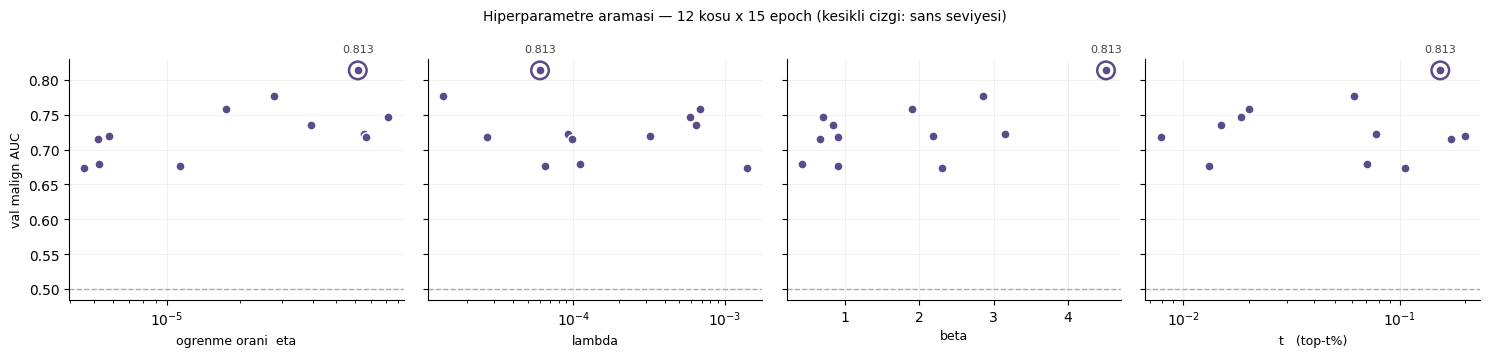


/content/drive/MyDrive/multiple_instance_classifier/arama/arama_dagilim.png


In [34]:
ARAMA_OZET = ARAMA_DIR / 'arama_ozeti.xlsx'
SECIM_JSON = ARAMA_DIR / 'secim.json'
ARAMA_PNG = ARAMA_DIR / 'arama_dagilim.png'

# sonuclar diskten toplanir: oturum koptuysa da eldeki kosularla ozet cikar
kayitlar = [json.loads(p.read_text(encoding='utf-8'))
            for p in sorted(ARAMA_DIR.glob('kosu_*/sonuc.json'))]
assert kayitlar, 'bitmis kosu yok -- once ARAMA_KOS = True ile aramayi baslatin'

ar = pd.DataFrame(kayitlar).sort_values('best_auc', ascending=False).reset_index(drop=True)
ar.to_excel(ARAMA_OZET, index=False)
print(ar[['id', 'lr', 'lam', 'beta', 't', 'best_auc', 'dakika', 'durum']].to_string(
    index=False, formatters=BICIM))

basarili = ar[ar.durum == 'tamam'].dropna(subset=['best_auc'])
print(f'\n{len(ar)} kosu, {len(basarili)} basarili | {ARAMA_OZET.name}')
assert len(basarili) >= 3, f'ensemble icin en az 3 basarili kosu gerekiyor, {len(basarili)} var'

en_iyi = basarili.iloc[0]
top3 = basarili.head(3)
secim = dict(HP=dict(lr=float(en_iyi.lr), lam=float(en_iyi.lam),
                     beta=float(en_iyi.beta), t=float(en_iyi.t)),
             en_iyi_id=int(en_iyi.id), en_iyi_auc=float(en_iyi.best_auc),
             top3_id=[int(i) for i in top3.id],
             top3_auc=[float(a) for a in top3.best_auc],
             top3_hp=[dict(lr=float(r.lr), lam=float(r.lam), beta=float(r.beta), t=float(r.t))
                      for r in top3.itertuples()],
             arama=dict(n_kosu=len(ar), n_basarili=len(basarili),
                        epoch=ARAMA_EPOCH, patience=ARAMA_PATIENCE))
SECIM_JSON.write_text(json.dumps(secim, indent=2), encoding='utf-8')

print(f'\nen iyi: kosu {secim["en_iyi_id"]:02d}, val malign AUC {secim["en_iyi_auc"]:.4f}')
print(f'top 3 : kosu {secim["top3_id"]} AUC '
      f'{[round(a, 4) for a in secim["top3_auc"]]}  (Parca 8 ensemble)')
print('\nHucre 3 teki HP satirini bununla degistirin:')
print(f'HP = dict(lr={en_iyi.lr:.6e}, lam={en_iyi.lam:.6e}, '
      f'beta={en_iyi.beta:.4f}, t={en_iyi.t:.5f})')

# --- dagilim grafigi: tek seri, tek hue, en iyi nokta isaretli
TEK_HUE = '#5B4B8A'
fig, axlar = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
panel = [('lr', 'ogrenme orani  eta', True), ('lam', 'lambda', True),
         ('beta', 'beta', False), ('t', 't   (top-t%)', True)]
for ax, (kol, etiket, log_x) in zip(axlar, panel):
    ax.axhline(0.5, color='#AAAAAA', linewidth=1, linestyle='--', zorder=1)
    ax.scatter(basarili[kol], basarili.best_auc, s=44, color=TEK_HUE,
               edgecolor='white', linewidth=1.1, zorder=3)
    ax.scatter([en_iyi[kol]], [en_iyi.best_auc], s=160, facecolor='none',
               edgecolor=TEK_HUE, linewidth=1.8, zorder=4)
    ax.annotate(f'{en_iyi.best_auc:.3f}', (en_iyi[kol], en_iyi.best_auc),
                textcoords='offset points', xytext=(0, 13), ha='center',
                fontsize=8, color='#444444')
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(etiket, fontsize=9)
    ax.grid(True, alpha=0.22, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axlar[0].set_ylabel('val malign AUC', fontsize=9)
fig.suptitle(f'Hiperparametre aramasi — {len(basarili)} kosu x {ARAMA_EPOCH} epoch '
             f'(kesikli cizgi: sans seviyesi)', fontsize=10)
fig.tight_layout()
fig.savefig(ARAMA_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n{ARAMA_PNG}')

In [ ]:
print(BATCH, GRAD_ACCUM)


## Parca 8 — Tam egitimler

Parca 7'nin sectigi konfigurasyon **sabit**; degisen tek sey ablasyonun kendisi. Kosu sirasi
onem sirasina gore: `gmic` (tam model) ve `resnet22_baseline` once, cunku raporun ana
karsilastirmasi bu ikisi.

| # | `DENEY_KEY` | Ne degisiyor |
|---|---|---|
| 1 | `gmic` | — (tam model, referans) |
| 2 | `resnet22_baseline` | GMIC yok: `f_d` + GAP + FC |
| 3 | `gmic_noattn` | `alpha_k = 1/K` (gated attention kapali) |
| 4 | `gmic_random` | MIL rastgele yamalarda (Algoritma 1 devre disi) |
| 5 | `gmic_ft_scratch` | `f_t` ImageNet on-egitimi olmadan |
| 6 | `gmic_lowres` | 1152 x 640 (`lambda` alan oraniyla x4) |
| 7 | `gmic_augment` | ek augmentasyon (makalede yok) |
| 8-9 | `gmic_hp2`, `gmic_hp3` | aramanin 2. ve 3. konfigurasyonu -> ensemble |

Uc sey her kosuda otomatik:

- **Resume**: `last.pt` varsa kaldigi epoch'tan devam eder. Oturum koparsa hucreyi bastan
  calistirmak yeterli.
- **Atlama**: `<key>_test_summary.xlsx` varsa deney bitmis sayilir, tekrar egitilmez.
- **Test degerlendirmesi**: en iyi checkpoint yuklenir, test kumesi meme seviyesinde
  degerlendirilir; tahminler ve alt grup kirilimi (D1/D2, `abnormality`, `Age`) Parca 9'un
  girdisi olarak Excel'e yazilir.

> Batch 4 ve `GRAD_ACCUM = 4` **degistirilmemeli**: secilen `lr` bu batch altinda bulundu.

Kayit: vaka gorselleri (makalenin Sekil 4 karsiligi) burada uretilmiyor -- Parca 10'da kayitli
checkpointlerden uretilecek, boylece figur duzeni degistiginde egitim tekrarlanmiyor.

In [35]:
import time   # kalibrasyon hucresi atlanirsa da tanimli olsun

# Parca 7 ciktisi tek kaynak: secim.json
with open(ARAMA_DIR / 'secim.json', encoding='utf-8') as f:
    SECIM = json.load(f)
HP_SECIM = dict(SECIM['HP'])
assert abs(HP_SECIM['lr'] - HP['lr']) < 1e-12, 'hucre 3 teki HP secim.json ile ayni degil'
print('secilen HP:', {k: f'{v:.6g}' for k, v in HP_SECIM.items()},
      f"| kosu {SECIM['en_iyi_id']:02d}, val malign AUC {SECIM['en_iyi_auc']:.4f}")

# ensemble kosulari: aramanin 2. ve 3. konfigurasyonu
for sira, ad in [(1, 'gmic_hp2'), (2, 'gmic_hp3')]:
    DENEYLER[ad] = dict(mimari='gmic', hp=dict(SECIM['top3_hp'][sira]),
                        not_=f"arama {sira + 1}. sirasi (kosu {SECIM['top3_id'][sira]:02d}), ensemble")

TAM_SIRA = ['gmic', 'resnet22_baseline', 'gmic_noattn', 'gmic_random',
            'gmic_ft_scratch', 'gmic_lowres', 'gmic_augment']
ENSEMBLE_SIRA = ['gmic_hp2', 'gmic_hp3']
NATIVE_SIZE = tuple(VERI_CFG['GLOBAL_SIZE'])


def deney_ayarla(key):
    """DENEY_KEY'e bagli tum global'leri yeniden kurar (hucre 3 un deney basina karsiligi)."""
    global DENEY_KEY, CFG, GLOBAL_SIZE, HP, DENEY_DIR, CKPT_DIR, CASES_DIR
    global EXCEL_LOG, CURVES_PNG, BEST_CKPT, LAST_CKPT, TEST_OZET, TEST_TAHMIN

    DENEY_KEY = key
    CFG = dict(DENEYLER[key])
    assert 'turetilmis' not in CFG, f'{key} egitilmez, Parca 9 turetir'

    GLOBAL_SIZE = tuple(CFG.get('global_size', NATIVE_SIZE))
    HP = dict(HP_SECIM)
    HP.update(CFG.get('hp', {}))
    # L_reg bir toplam -> saliency map alaniyla olcekleniyor. Cozunurluk dususte ayni
    # regularization baskisini korumak icin lambda alan oraniyla carpilir (Bolum 3).
    alan_orani = (NATIVE_SIZE[0] * NATIVE_SIZE[1]) / (GLOBAL_SIZE[0] * GLOBAL_SIZE[1])
    HP['lam'] *= alan_orani

    DENEY_DIR = KOK / key
    CKPT_DIR = DENEY_DIR / 'checkpoints'
    CASES_DIR = DENEY_DIR / f'{key}_cases'
    for d in [DENEY_DIR, CKPT_DIR, CASES_DIR, YEREL_AYNA / key]:
        d.mkdir(parents=True, exist_ok=True)

    EXCEL_LOG = DENEY_DIR / f'{key}_log.xlsx'
    CURVES_PNG = DENEY_DIR / f'{key}_curves.png'
    BEST_CKPT = CKPT_DIR / 'best.pt'
    LAST_CKPT = CKPT_DIR / 'last.pt'
    TEST_OZET = DENEY_DIR / f'{key}_test_summary.xlsx'
    TEST_TAHMIN = DENEY_DIR / f'{key}_test_tahminler.xlsx'
    return CFG


for k in TAM_SIRA + ENSEMBLE_SIRA:
    c = deney_ayarla(k)
    ek = ' lam x{:.0f}'.format((NATIVE_SIZE[0] * NATIVE_SIZE[1]) /
                               (GLOBAL_SIZE[0] * GLOBAL_SIZE[1])) if GLOBAL_SIZE != NATIVE_SIZE else ''
    print(f"{k:20s} {str(GLOBAL_SIZE):14s} lr {HP['lr']:.2e} lam {HP['lam']:.2e} "
          f"beta {HP['beta']:.3f} t {HP['t']:.4f}{ek}  | {c['not_']}")

AssertionError: hucre 3 teki HP secim.json ile ayni degil

In [ ]:
# meme -> klinik bilgi (alt grup kirilimi Parca 9'da bu kolonlardan cikacak)
MEME_META = (manifest.drop_duplicates('meme')
             .set_index('meme')[['hasta', 'taraf', 'classification', 'abnormality',
                                 'Age', 'subtype', 'grup', 'split']])


@torch.no_grad()
def test_degerlendir(model, boyut, epoch, val_auc):
    """Test kumesini meme seviyesinde degerlendirir; tahmin tablosu + ozet dondurur."""
    tab = manifest[manifest.split == 'test']
    ds = MemeVeri(tab, boyut, egitim=False)
    yuk = DataLoader(ds, batch_size=BATCH, shuffle=False,
                     num_workers=(0 if ORTAM == 'yerel' else 2),
                     pin_memory=(DEVICE == 'cuda'))
    m, toplam = dogrula(model, yuk)

    p, etiket = meme_seviyesi(toplam['y'], toplam['meme'], toplam['gercek'])
    p_loc, _ = meme_seviyesi(toplam['y_loc'], toplam['meme'], toplam['gercek'])
    p_mil, _ = meme_seviyesi(toplam['y_mil'], toplam['meme'], toplam['gercek'])
    memeler = [KOD_MEME[k] for k in sorted(set(toplam['meme']))]

    tahmin = pd.DataFrame({'meme': memeler,
                           'y_malign': etiket[:, 1], 'y_benign': etiket[:, 0],
                           'p_malign': p[:, 1], 'p_benign': p[:, 0],
                           'p_loc_malign': p_loc[:, 1], 'p_mil_malign': p_mil[:, 1]})
    tahmin = tahmin.join(MEME_META, on='meme')
    assert len(tahmin) == tab.meme.nunique(), (len(tahmin), tab.meme.nunique())
    tahmin.to_excel(TEST_TAHMIN, index=False)

    # ozet: genel + alt kume kirilimi. D1 birincil kohort (confounder gerekcesi Bolum 1).
    satirlar_ = []
    for ad, alt in [('tumu', tahmin), ('D1', tahmin[tahmin.grup == 'D1']),
                    ('D2', tahmin[tahmin.grup == 'D2'])]:
        satirlar_.append(dict(
            deney=DENEY_KEY, kohort=ad, n_meme=len(alt),
            n_malign=int(alt.y_malign.sum()),
            auc_malign=guvenli_auc(alt.y_malign.to_numpy(), alt.p_malign.to_numpy()),
            auc_malign_loc=guvenli_auc(alt.y_malign.to_numpy(), alt.p_loc_malign.to_numpy()),
            auc_malign_mil=guvenli_auc(alt.y_malign.to_numpy(), alt.p_mil_malign.to_numpy()),
            auc_benign=guvenli_auc(alt.y_benign.to_numpy(), alt.p_benign.to_numpy()),
            val_auc_malign=val_auc, best_epoch=epoch,
            global_size=str(GLOBAL_SIZE), batch=BATCH, grad_accum=GRAD_ACCUM,
            efektif_batch=BATCH * GRAD_ACCUM,
            **{f'hp_{k}': v for k, v in HP.items()}))
    ozet = pd.DataFrame(satirlar_)
    ozet.to_excel(TEST_OZET, index=False)
    for y in [TEST_TAHMIN, TEST_OZET]:
        mirror_to_local(y)
    return ozet, tahmin

In [ ]:
def deneyi_kos(key, max_epochs=None, zorla=False):
    deney_ayarla(key)
    if TEST_OZET.exists() and not zorla:
        o = pd.read_excel(TEST_OZET)
        d1 = o[o.kohort == 'D1'].auc_malign.iloc[0]
        print(f"{key:20s} atlandi (bitmis) | test D1 malign AUC {d1:.4f}")
        return o

    print(f"\n{'=' * 78}\n{key}  ({CFG['not_']})  |  {GLOBAL_SIZE}  |  "
          f"lr {HP['lr']:.2e} lam {HP['lam']:.2e} beta {HP['beta']:.3f} t {HP['t']:.4f}\n{'=' * 78}")
    t0 = time.time()
    veri, egt_y, dgr_y = yukleyiciler(GLOBAL_SIZE)
    resume = LAST_CKPT.exists()
    model, best = egit(GLOBAL_SIZE, max_epochs or MAX_EPOCHS, veri, egt_y, dgr_y,
                       EXCEL_LOG, resume=resume)
    plot_training_curves(EXCEL_LOG, CURVES_PNG, f'{key} — val malign AUC {best:.4f}')
    for y in [EXCEL_LOG, CURVES_PNG]:
        mirror_to_local(y)

    # test her zaman EN IYI checkpoint ile (son epoch degil)
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model = model_kur()
    opt = torch.optim.Adam(model.parameters(), lr=HP['lr'])
    ep, val_auc, _ = restore_checkpoint(ckpt, model, opt, None)
    ozet, tahmin = test_degerlendir(model, GLOBAL_SIZE, ep, val_auc)

    print(f"\n{key} bitti ({(time.time() - t0) / 60:.0f} dk) | en iyi epoch {ep} "
          f"(val malign AUC {val_auc:.4f})")
    print(ozet[['kohort', 'n_meme', 'n_malign', 'auc_malign',
                'auc_malign_loc', 'auc_malign_mil', 'auc_benign']].to_string(index=False))
    del model, opt
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return ozet


EGITIM_KOS = True       # Parca 8: sirayla tum deneyleri kosar (resume + atlama otomatik)
ENSEMBLE_DAHIL = True   # aramanin 2. ve 3. konfigurasyonunu da egit (ensemble icin)

SIRA = TAM_SIRA + (ENSEMBLE_SIRA if ENSEMBLE_DAHIL else [])

if EGITIM_KOS:
    ozetler, bas = [], time.time()
    for i, key in enumerate(SIRA, 1):
        ozetler.append(deneyi_kos(key))
        gecen = (time.time() - bas) / 60
        print(f'--- ilerleme {i}/{len(SIRA)} | gecen {gecen:.0f} dk ---')
    print('\ntum deneyler bitti.')
else:
    print(f'EGITIM_KOS = False -- egitim baslatilmadi. Sira ({len(SIRA)} kosu):')
    print('  ' + ' -> '.join(SIRA))

In [ ]:
# --- eldeki tum deney ozetlerini birlestir (Parca 9'un girdisi)
KARSILASTIRMA = KOK / 'karsilastirma_ozeti.xlsx'
bulunan = []
for key in TAM_SIRA + ENSEMBLE_SIRA:
    p = KOK / key / f'{key}_test_summary.xlsx'
    if p.exists():
        bulunan.append(pd.read_excel(p))
assert bulunan, 'bitmis deney yok -- once EGITIM_KOS = True ile egitimi baslatin'

karsi = pd.concat(bulunan, ignore_index=True)
karsi.to_excel(KARSILASTIRMA, index=False)
print(f'{karsi.deney.nunique()} deney | {KARSILASTIRMA}\n')

d1 = (karsi[karsi.kohort == 'D1']
      .sort_values('auc_malign', ascending=False)
      [['deney', 'n_meme', 'auc_malign', 'auc_malign_loc', 'auc_malign_mil',
        'auc_benign', 'val_auc_malign', 'best_epoch']])
print('test D1 kohortu (birincil), malign AUC ye gore sirali')
print(d1.to_string(index=False))